In [17]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import euclidean_distances
from sklearn.metrics import confusion_matrix, classification_report, f1_score,accuracy_score, precision_score, recall_score
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
import numpy as np
import pickle
from model import ZENA, ZMAD

In [ ]:
# Label Conversion
def label_conversion(df):
    df.loc[df['Labels'] == 'abnormal', 'Labels'] = 1
    df.loc[df['Labels'] == 'normal', 'Labels'] = 0
    df['Labels'].astype(int)
    return df

# Data Split
def data_splitter(data, train_ratio=0.8, val_ratio=0.1, test_ratio=0.1, random_seed=42):

    if train_ratio+val_ratio+test_ratio != 1 :
        print(f"Ratio setting is not correct : {train_ratio}+{val_ratio}+{test_ratio} != 1")

    if random_seed is not None:
        np.random.seed(random_seed)

    print(f"Total data count : {len(data)}")
    
    # Mixing up indices
    shuffled_indices = np.random.permutation(data.index)

    # Set the split point
    train_split_point = int(len(data)*train_ratio)
    validation_split_point = int(len(data)*(train_ratio+val_ratio))

    # Separate indices
    train_indices = shuffled_indices[:train_split_point]
    val_indices = shuffled_indices[train_split_point:validation_split_point]
    test_indices = shuffled_indices[validation_split_point:]

    # Assign df data according to the indices
    train_data = data.loc[train_indices].reset_index(drop=True)
    val_data = data.loc[val_indices].reset_index(drop=True)
    test_data = data.loc[test_indices].reset_index(drop=True)

    print(train_data['Labels'].value_counts())
    print(val_data['Labels'].value_counts())
    print(test_data['Labels'].value_counts())
    print('*'*100)
    
    # Split X, Y
    train_X = np.array(train_data.iloc[:, :-1], dtype=int).T
    train_Y = np.array(train_data.iloc[:, -1], dtype=int)
    val_X = np.array(val_data.iloc[:, :-1], dtype=int).T
    val_Y = np.array(val_data.iloc[:, -1], dtype=int)
    test_X = np.array(test_data.iloc[:, :-1], dtype=int).T
    test_Y = np.array(test_data.iloc[:, -1], dtype=int)

    return train_X, train_Y, val_X, val_Y, test_X, test_Y

def history_chart(train_loss_history, val_loss_history):
    plt.plot(train_loss_history, label='Training Loss')
    plt.plot(val_loss_history, label='Validation Loss')
    plt.xlabel('Iterations (per 1000)')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss')
    plt.legend()
    plt.show()
    return

def get_confusion_matrix(model, test_x, test_y):
    yhat_test = model.predict(test_x)
    accuracy = accuracy_score(test_y, yhat_test)
    confusion_mat = confusion_matrix(test_y, yhat_test)
    classification = classification_report(test_y, yhat_test)
    f1 = f1_score(test_y, yhat_test, average='weighted')

    print()
    print('============================== ZMAD ANN Model Test Results ==============================')
    print()
    print ("Model Accuracy:" "\n", accuracy)
    print()
    print("Confusion matrix:" "\n", confusion_mat)
    print()
    print("Classification report:" "\n", classification) 
    print() 
    return accuracy, f1

# ZENA Training

In [20]:
# Data Loader
data = pd.read_csv("ZENA_data.csv")
train_x, train_y, val_x, val_y, test_x, test_y = data_splitter(data)

Total data count : 74505
Labels
1    36478
0    23126
Name: count, dtype: int64
Labels
1    4584
0    2866
Name: count, dtype: int64
Labels
1    4606
0    2845
Name: count, dtype: int64
****************************************************************************************************


In [28]:
# Model Init
model = ZENA(
    input_size=30,
    hidden_size1=128,
    hidden_size2=32,
    learning_rate=0.03,
    iterations=100000,
    early_stopping_rounds=5000,
    tolerance=1e-4,
    init_method='xavier',
    momentum=0.9)

In [29]:
# Model Train
train_loss_history, val_loss_history = model.fit(train_x, train_y, val_x, val_y)
accuracy, f1 = get_confusion_matrix(model, test_x, test_y)

Iteration: 0
Training Loss: 3.91824590293955
Validation Loss: 2.2345674673892
Iteration: 1000
Training Loss: 0.20056310777603267
Validation Loss: 0.2244499063035069
Iteration: 2000
Training Loss: 0.17809939045303633
Validation Loss: 0.2039844514771611
Iteration: 3000
Training Loss: 0.17970956837424185
Validation Loss: 0.19591672561560733
Iteration: 4000
Training Loss: 0.1513777074861013
Validation Loss: 0.17086731935807728
Iteration: 5000
Training Loss: 0.14529462124694056
Validation Loss: 0.1664706013402552
Iteration: 6000
Training Loss: 0.15152037656224301
Validation Loss: 0.16587323609043558
Iteration: 7000
Training Loss: 0.13889953565367721
Validation Loss: 0.16256313813600573
Iteration: 8000
Training Loss: 0.14574425898209986
Validation Loss: 0.17485866965512492
Iteration: 9000
Training Loss: 0.14138125386956227
Validation Loss: 0.1669339981400859
Iteration: 10000
Training Loss: 0.16575226855904435
Validation Loss: 0.16881533468120338
Iteration: 11000
Training Loss: 0.132072587995

In [30]:
model.save_params("params/ZENA_main.pkl")

Parameters saved to ZENA_main.pkl


# Visualization

In [32]:
def get_confusion_matrix(model, test_x, test_y, pic_title=""):
    yhat_test = model.predict(test_x)
    accuracy = accuracy_score(test_y, yhat_test)
    confusion_mat = confusion_matrix(test_y, yhat_test)
    classification = classification_report(test_y, yhat_test)
    f1 = f1_score(test_y, yhat_test, average='weighted')
    
    # Calculate precision and recall
    precision = precision_score(test_y, yhat_test, average='weighted')
    recall = recall_score(test_y, yhat_test, average='weighted')

    print()
    print('============================== ZMAD ANN Model Test Results ==============================')
    print()
    print("Model Accuracy:" "\n", f"{accuracy:.4f}")
    print()
    print("Confusion matrix:" "\n", confusion_mat)
    print()
    print("Classification report:" "\n", classification) 
    print()
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score : {f1:.4f}")
    
    plt.rcParams['axes.labelsize'] = 18
    plt.rcParams['axes.titlesize'] = 18
    plt.rcParams['xtick.labelsize'] = 18
    plt.rcParams['ytick.labelsize'] = 18
    
    # Plotting the confusion matrix with increased font size
    plt.figure(figsize=(8, 6))
    sns.heatmap(confusion_mat, annot=True, fmt='d', cmap='Blues', cbar=False,
                annot_kws={"size": 30})  # Increase font size here
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    
    if pic_title:
        plt.savefig('images/'+pic_title+'.png')
    
    plt.show()

    return accuracy, f1


============================== ZMAD ANN Model Test Results ==============================

Model Accuracy:
 0.9591

Confusion matrix:
 [[21543  1583]
 [  854 35624]]

Classification report:
               precision    recall  f1-score   support

           0       0.96      0.93      0.95     23126
           1       0.96      0.98      0.97     36478

    accuracy                           0.96     59604
   macro avg       0.96      0.95      0.96     59604
weighted avg       0.96      0.96      0.96     59604


Precision: 0.9592
Recall: 0.9591
F1 Score : 0.9590


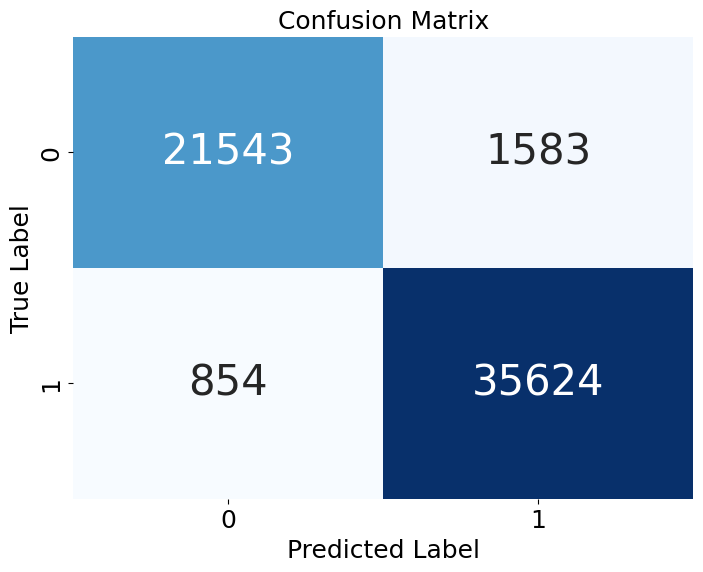

In [36]:
accuracy, f1 = get_confusion_matrix(model, train_x, train_y, pic_title="ZENA_train")


============================== ZMAD ANN Model Test Results ==============================

Model Accuracy:
 0.9516

Confusion matrix:
 [[2610  235]
 [ 126 4480]]

Classification report:
               precision    recall  f1-score   support

           0       0.95      0.92      0.94      2845
           1       0.95      0.97      0.96      4606

    accuracy                           0.95      7451
   macro avg       0.95      0.95      0.95      7451
weighted avg       0.95      0.95      0.95      7451


Precision: 0.9516
Recall: 0.9516
F1 Score : 0.9514


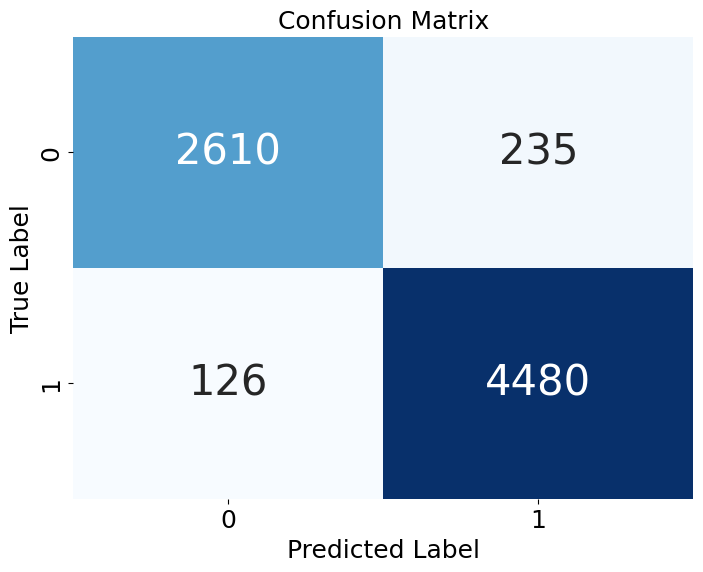

In [35]:
accuracy, f1 = get_confusion_matrix(model, test_x, test_y, pic_title="ZENA_test")

# Ablation study
- This is a reproduction of Table 5 and Table 6, which show the robustness of ZENA model over ZMAD through cross-data validation.
- This test was to see the generalizability of the model when confronted with unseen data.

In [78]:
original_data = pd.read_csv("Original_data.csv")
enhanced_data = pd.read_csv("Enhanced_data.csv")

## Table 5. Test on ZMAD model

In [99]:
train_x, train_y, val_x, val_y, test_x, test_y = data_splitter(original_data)
ZMAD_origin = ZMAD(
    input_size=30,
    hidden_size=28,
    learning_rate=0.01,
    iterations=100000
)
ZMAD_origin.fit(train_x, train_y, val_x, val_y)

Total data count : 10496
Labels
0    4279
1    4117
Name: count, dtype: int64
Labels
1    527
0    523
Name: count, dtype: int64
Labels
1    527
0    523
Name: count, dtype: int64
****************************************************************************************************
Iteration: 0
Training Loss: 0.12768438776385835
Validation Loss: 0.12065098938685573
Iteration: 1000
Training Loss: 0.05225608922096725
Validation Loss: 0.059266336997719604
Iteration: 2000
Training Loss: 0.03326249540225424
Validation Loss: 0.040135091980661626
Iteration: 3000
Training Loss: 0.023269432762944926
Validation Loss: 0.027906622469964826
Iteration: 4000
Training Loss: 0.02035870422108303
Validation Loss: 0.024424044177343115
Iteration: 5000
Training Loss: 0.018322436324886227
Validation Loss: 0.02208721566913369
Iteration: 6000
Training Loss: 0.017969764825812543
Validation Loss: 0.02175911951121826
Iteration: 7000
Training Loss: 0.017108429834033042
Validation Loss: 0.02073468037852499
Iteration:

([np.float64(0.12768438776385835),
  np.float64(0.05225608922096725),
  np.float64(0.03326249540225424),
  np.float64(0.023269432762944926),
  np.float64(0.02035870422108303),
  np.float64(0.018322436324886227),
  np.float64(0.017969764825812543),
  np.float64(0.017108429834033042),
  np.float64(0.01708105966398028),
  np.float64(0.016825323410621054),
  np.float64(0.016136152588049558),
  np.float64(0.0159598463731643),
  np.float64(0.016075775215055717),
  np.float64(0.015894845886512778),
  np.float64(0.01584863549593075),
  np.float64(0.015523083357726624),
  np.float64(0.015030913423524516),
  np.float64(0.014955873676981602),
  np.float64(0.01461923567490009),
  np.float64(0.01456006006119615),
  np.float64(0.014241330611644164),
  np.float64(0.014199027417740057),
  np.float64(0.013901364411278866),
  np.float64(0.01378646513567799),
  np.float64(0.013858244145996738),
  np.float64(0.013752887374984493),
  np.float64(0.013621318463754199),
  np.float64(0.013485605677772242),
  n

In [125]:
ZMAD_origin = ZMAD()
ZMAD_origin.load_params("../params/ZMAD_original.pkl")

Parameters loaded from ../params/ZMAD_original.pkl



============================== ZMAD ANN Model Test Results ==============================

Model Accuracy:
 0.7781

Confusion matrix:
 [[491  32]
 [201 326]]

Classification report:
               precision    recall  f1-score   support

           0       0.71      0.94      0.81       523
           1       0.91      0.62      0.74       527

    accuracy                           0.78      1050
   macro avg       0.81      0.78      0.77      1050
weighted avg       0.81      0.78      0.77      1050


Precision: 0.8105
Recall: 0.7781
F1 Score : 0.7723


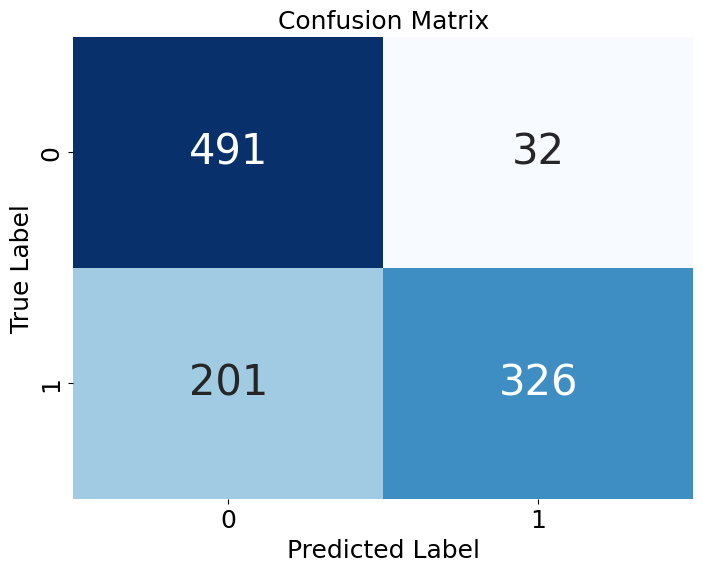

In [126]:
accuracy, f1 = get_confusion_matrix(ZMAD_origin, test_x, test_y, pic_title="ZMAD_origin_test")

In [127]:
cross_x = np.array(enhanced_data.iloc[:, :-1], dtype=int).T
cross_y = np.array(enhanced_data.iloc[:, -1], dtype=int)


============================== ZMAD ANN Model Test Results ==============================

Model Accuracy:
 0.7437

Confusion matrix:
 [[18576  4936]
 [11468 29029]]

Classification report:
               precision    recall  f1-score   support

           0       0.62      0.79      0.69     23512
           1       0.85      0.72      0.78     40497

    accuracy                           0.74     64009
   macro avg       0.74      0.75      0.74     64009
weighted avg       0.77      0.74      0.75     64009


Precision: 0.7678
Recall: 0.7437
F1 Score : 0.7481


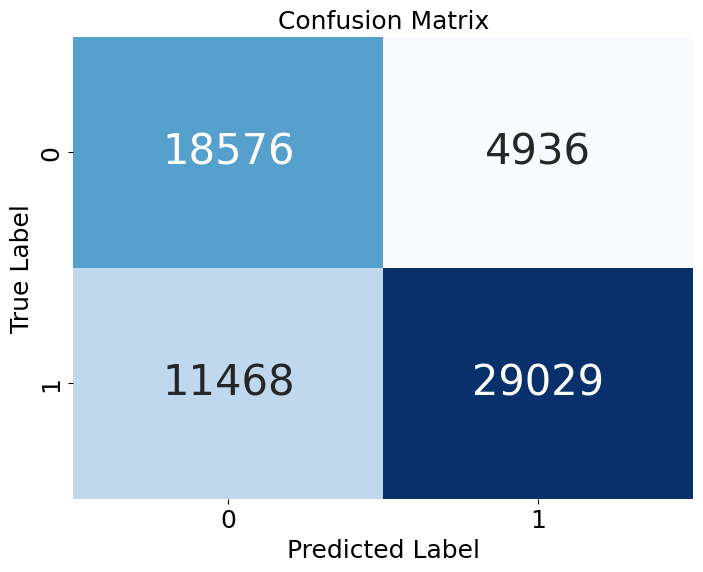

In [102]:
accuracy, f1=  get_confusion_matrix(ZMAD_origin, cross_x, cross_y, pic_title="ZMAD_origin_cross")

In [103]:
ZMAD_origin.save_params("params/ZMAD_origin.pkl")

Parameters saved to params/ZMAD_origin.pkl


In [128]:
train_x, train_y, val_x, val_y, test_x, test_y = data_splitter(enhanced_data)
ZMAD_enhanced = ZMAD(
    input_size=30,
    hidden_size=28,
    learning_rate=0.01,
    iterations=100000
)
ZMAD_enhanced.fit(train_x, train_y, val_x, val_y)

Total data count : 64009
Labels
1    32355
0    18852
Name: count, dtype: int64
Labels
1    4112
0    2289
Name: count, dtype: int64
Labels
1    4030
0    2371
Name: count, dtype: int64
****************************************************************************************************
Iteration: 0
Training Loss: 0.12271155000608475
Validation Loss: 0.11606638289219864


KeyboardInterrupt: 

In [129]:
ZMAD_enhanced = ZMAD()
ZMAD_enhanced.load_params("../params/ZMAD_swap.pkl")

Parameters loaded from ../params/ZMAD_swap.pkl



============================== ZMAD ANN Model Test Results ==============================

Model Accuracy:
 0.9345

Confusion matrix:
 [[2157  214]
 [ 205 3825]]

Classification report:
               precision    recall  f1-score   support

           0       0.91      0.91      0.91      2371
           1       0.95      0.95      0.95      4030

    accuracy                           0.93      6401
   macro avg       0.93      0.93      0.93      6401
weighted avg       0.93      0.93      0.93      6401


Precision: 0.9345
Recall: 0.9345
F1 Score : 0.9345


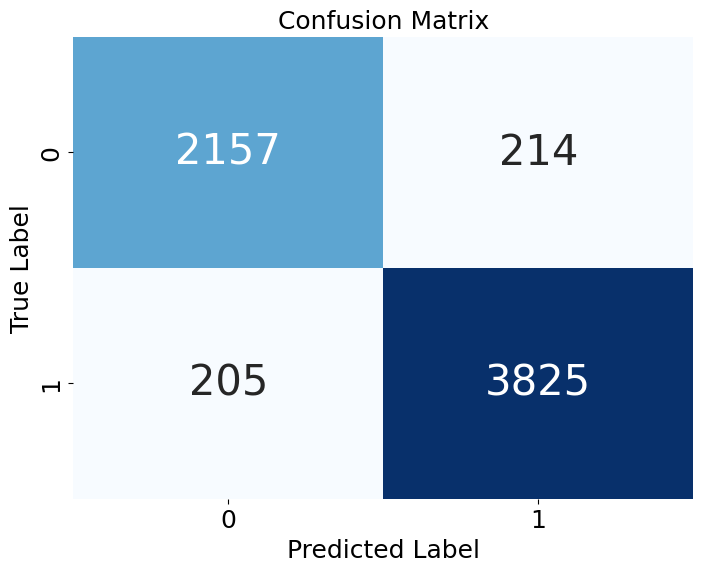

In [130]:
accuracy, f1 = get_confusion_matrix(ZMAD_enhanced, test_x, test_y, pic_title="ZMAD_enhanced_test")

In [131]:
cross_x = np.array(original_data.iloc[:, :-1], dtype=int).T
cross_y = np.array(original_data.iloc[:, -1], dtype=int)


============================== ZMAD ANN Model Test Results ==============================

Model Accuracy:
 0.6277

Confusion matrix:
 [[5008  317]
 [3591 1580]]

Classification report:
               precision    recall  f1-score   support

           0       0.58      0.94      0.72      5325
           1       0.83      0.31      0.45      5171

    accuracy                           0.63     10496
   macro avg       0.71      0.62      0.58     10496
weighted avg       0.71      0.63      0.59     10496


Precision: 0.7058
Recall: 0.6277
F1 Score : 0.5852


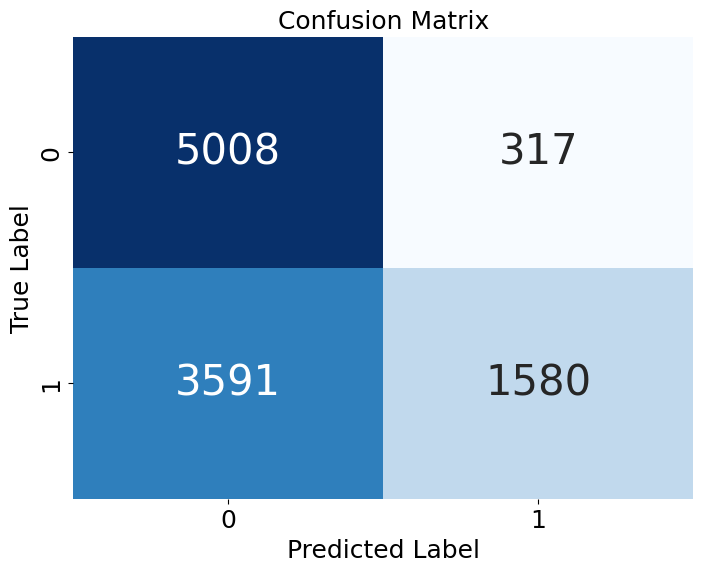

In [132]:
accuracy, f1=  get_confusion_matrix(ZMAD_enhanced, cross_x, cross_y, pic_title="ZMAD_enhanced_cross")

In [108]:
ZMAD_enhanced.save_params("params/ZMAD_enhanced.pkl")

Parameters saved to params/ZMAD_enhanced.pkl


## Table 6. Test on ZENA

In [120]:
train_x, train_y, val_x, val_y, test_x, test_y = data_splitter(original_data)
ZENA_origin = ZENA(
    input_size=30,
    hidden_size1=128,
    hidden_size2=32,
    learning_rate=0.03,
    iterations=100000,
    early_stopping_rounds=5000,
    tolerance=1e-4,
    init_method='xavier',
    momentum=0.9
)
ZENA_origin.fit(train_x, train_y, val_x, val_y)

Total data count : 10496
Labels
0    4279
1    4117
Name: count, dtype: int64
Labels
1    527
0    523
Name: count, dtype: int64
Labels
1    527
0    523
Name: count, dtype: int64
****************************************************************************************************
Iteration: 0
Training Loss: 9.941549845845776
Validation Loss: 4.517415881922038
Iteration: 1000
Training Loss: 0.13420651284485186
Validation Loss: 0.21230206776499377
Iteration: 2000
Training Loss: 0.07742702469764927
Validation Loss: 0.13184360671889633
Iteration: 3000
Training Loss: 0.0645413330750409
Validation Loss: 0.11924382191980404
Iteration: 4000
Training Loss: 0.051853020130192204
Validation Loss: 0.10338408338609538
Iteration: 5000
Training Loss: 0.08444924329301301
Validation Loss: 0.14586898127128853
Iteration: 6000
Training Loss: 0.057483175136041315
Validation Loss: 0.1191157926911544
Iteration: 7000
Training Loss: 0.14590782862218285
Validation Loss: 0.2084232184233839
Iteration: 8000
Trainin

([np.float64(9.941549845845776),
  np.float64(0.13420651284485186),
  np.float64(0.07742702469764927),
  np.float64(0.0645413330750409),
  np.float64(0.051853020130192204),
  np.float64(0.08444924329301301),
  np.float64(0.057483175136041315),
  np.float64(0.14590782862218285),
  np.float64(0.06843369070826553),
  np.float64(0.05922989295244594)],
 [np.float64(4.517415881922038),
  np.float64(0.21230206776499377),
  np.float64(0.13184360671889633),
  np.float64(0.11924382191980404),
  np.float64(0.10338408338609538),
  np.float64(0.14586898127128853),
  np.float64(0.1191157926911544),
  np.float64(0.2084232184233839),
  np.float64(0.13128410176349176),
  np.float64(0.12804991363949597)])


============================== ZMAD ANN Model Test Results ==============================

Model Accuracy:
 0.9581

Confusion matrix:
 [[515   8]
 [ 36 491]]

Classification report:
               precision    recall  f1-score   support

           0       0.93      0.98      0.96       523
           1       0.98      0.93      0.96       527

    accuracy                           0.96      1050
   macro avg       0.96      0.96      0.96      1050
weighted avg       0.96      0.96      0.96      1050


Precision: 0.9594
Recall: 0.9581
F1 Score : 0.9581


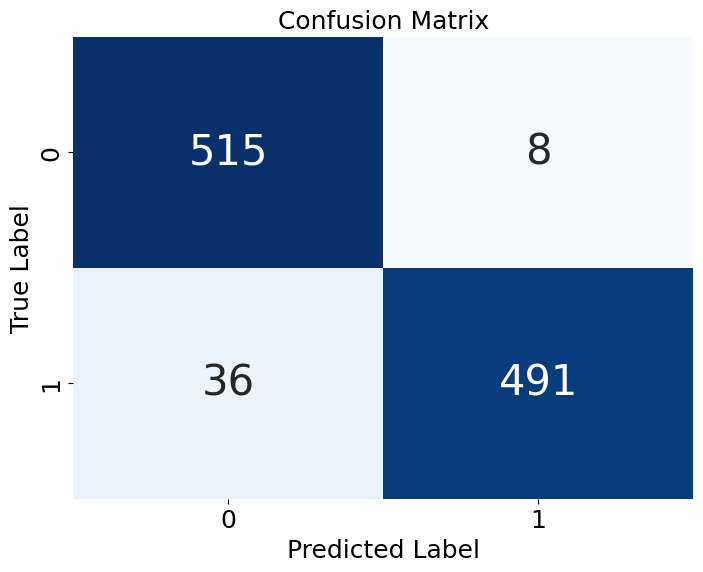

In [121]:
accuracy, f1 = get_confusion_matrix(ZENA_origin, test_x, test_y, pic_title="ZENA_origin_test")

In [122]:
cross_x = np.array(enhanced_data.iloc[:, :-1], dtype=int).T
cross_y = np.array(enhanced_data.iloc[:, -1], dtype=int)


============================== ZMAD ANN Model Test Results ==============================

Model Accuracy:
 0.4811

Confusion matrix:
 [[14110  9402]
 [23810 16687]]

Classification report:
               precision    recall  f1-score   support

           0       0.37      0.60      0.46     23512
           1       0.64      0.41      0.50     40497

    accuracy                           0.48     64009
   macro avg       0.51      0.51      0.48     64009
weighted avg       0.54      0.48      0.49     64009


Precision: 0.5414
Recall: 0.4811
F1 Score : 0.4858


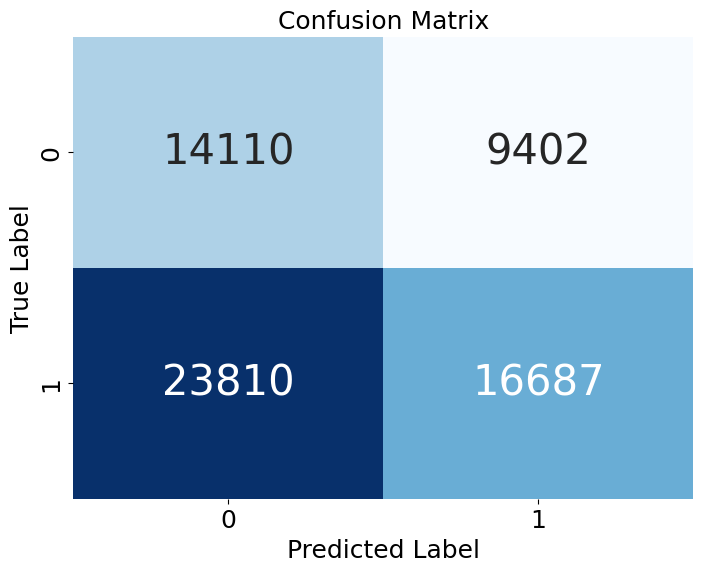

In [124]:
accuracy, f1=  get_confusion_matrix(ZENA_origin, cross_x, cross_y, pic_title="ZENA_origin_cross")

In [118]:
ZENA_origin.save_params("params/ZENA_origin.pkl")

Parameters saved to params/ZENA_origin.pkl


In [94]:
train_x, train_y, val_x, val_y, test_x, test_y = data_splitter(enhanced_data)
ZENA_enhanced = ZENA(
    input_size=30,
    hidden_size1=128,
    hidden_size2=32,
    learning_rate=0.03,
    iterations=100000,
    early_stopping_rounds=5000,
    tolerance=1e-4,
    init_method='xavier',
    momentum=0.9
)
ZENA_enhanced.fit(train_x, train_y, val_x, val_y)

Total data count : 64009
Labels
1    32355
0    18852
Name: count, dtype: int64
Labels
1    4112
0    2289
Name: count, dtype: int64
Labels
1    4030
0    2371
Name: count, dtype: int64
****************************************************************************************************
Iteration: 0
Training Loss: 7.301284931539453
Validation Loss: 5.933440278755847
Iteration: 1000
Training Loss: 0.22586940348084375
Validation Loss: 0.23815570081934598
Iteration: 2000
Training Loss: 0.21048459335450428
Validation Loss: 0.2220123622295172
Iteration: 3000
Training Loss: 0.2026768493016204
Validation Loss: 0.2151234492582151
Iteration: 4000
Training Loss: 0.1972145761433512
Validation Loss: 0.20962159289441312
Iteration: 5000
Training Loss: 0.1930411673626152
Validation Loss: 0.20589860233643276
Iteration: 6000
Training Loss: 0.18893227233796536
Validation Loss: 0.2019948118984309
Iteration: 7000
Training Loss: 0.18219819154448766
Validation Loss: 0.19639734473434867
Iteration: 8000
Traini

([np.float64(7.301284931539453),
  np.float64(0.22586940348084375),
  np.float64(0.21048459335450428),
  np.float64(0.2026768493016204),
  np.float64(0.1972145761433512),
  np.float64(0.1930411673626152),
  np.float64(0.18893227233796536),
  np.float64(0.18219819154448766),
  np.float64(0.17848916233496448),
  np.float64(0.17532444066096453),
  np.float64(0.1719166173114134),
  np.float64(0.16962211695142204),
  np.float64(0.16729156480067087),
  np.float64(0.16535852599495174),
  np.float64(0.1638281590356108),
  np.float64(0.16276112426602202),
  np.float64(0.1618042917376622),
  np.float64(0.16045135542358988),
  np.float64(0.1596384711484886),
  np.float64(0.15894387765982915),
  np.float64(0.1583104267282616),
  np.float64(0.15763999224884467),
  np.float64(0.1570974288850052),
  np.float64(0.15670416291506986),
  np.float64(0.15633025644988913),
  np.float64(0.15581253643067214),
  np.float64(0.1555430671581256),
  np.float64(0.15495724031629687),
  np.float64(0.15472490009196488


============================== ZMAD ANN Model Test Results ==============================

Model Accuracy:
 0.9319

Confusion matrix:
 [[2022  349]
 [  87 3943]]

Classification report:
               precision    recall  f1-score   support

           0       0.96      0.85      0.90      2371
           1       0.92      0.98      0.95      4030

    accuracy                           0.93      6401
   macro avg       0.94      0.92      0.93      6401
weighted avg       0.93      0.93      0.93      6401


Precision: 0.9335
Recall: 0.9319
F1 Score : 0.9310


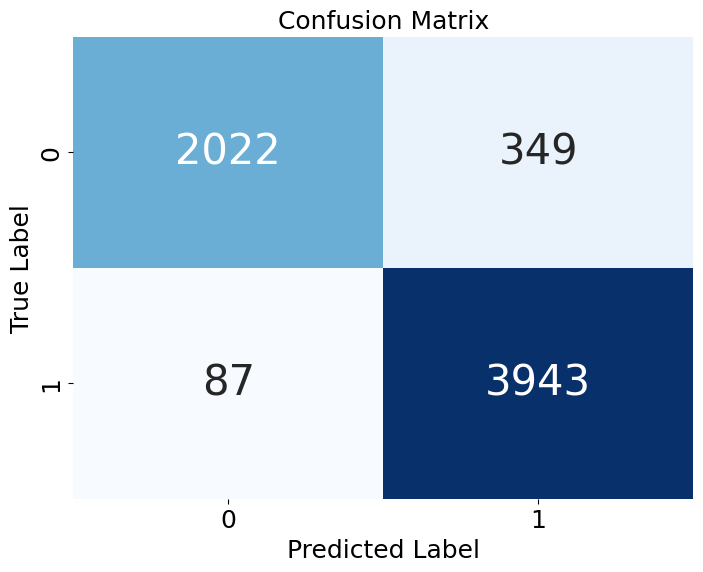

In [95]:
accuracy, f1 = get_confusion_matrix(ZENA_enhanced, test_x, test_y, pic_title="ZENA_enhanced_test")

In [96]:
cross_x = np.array(original_data.iloc[:, :-1], dtype=int).T
cross_y = np.array(original_data.iloc[:, -1], dtype=int)


============================== ZMAD ANN Model Test Results ==============================

Model Accuracy:
 0.6093

Confusion matrix:
 [[4550  775]
 [3326 1845]]

Classification report:
               precision    recall  f1-score   support

           0       0.58      0.85      0.69      5325
           1       0.70      0.36      0.47      5171

    accuracy                           0.61     10496
   macro avg       0.64      0.61      0.58     10496
weighted avg       0.64      0.61      0.58     10496


Precision: 0.6400
Recall: 0.6093
F1 Score : 0.5831


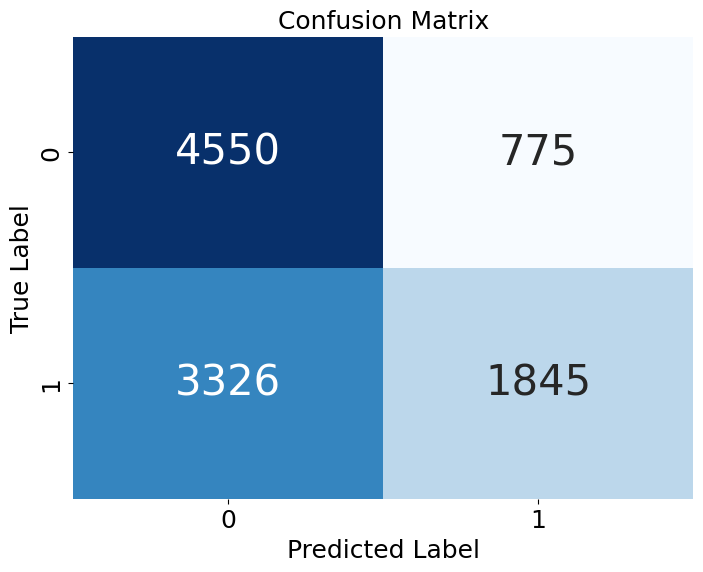

In [97]:
accuracy, f1 = get_confusion_matrix(ZENA_enhanced, cross_x, cross_y, pic_title="ZENA_enhanced_cross")

In [98]:
ZMAD_enhanced.save_params("params/ZENA_enhanced.pkl")

Parameters saved to params/ZENA_enhanced.pkl


# Figure 6 - PCA Visualization 

In [133]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import euclidean_distances
import seaborn as sns

In [136]:
ZMAD_data = pd.read_csv("ZMAD_data.csv").drop(columns=['Labels'])
ZENA_data = pd.read_csv("ZENA_data.csv").drop(columns=['Labels'])

In [ ]:
scaler = StandardScaler()
old_scaled_data = scaler.fit_transform(old_df)
ZMAD_pca=  

In [ ]:
original_data = pd.read_csv("Original_data.csv")
enhanced_data = pd.read_csv("Enhanced_data.csv")

In [52]:
enhanced_data = enhanced_data.merge(original_data.drop_duplicates(), how='left', indicator=True)
enhanced_data = enhanced_data[enhanced_data['_merge'] == 'left_only'].drop(columns=['_merge'])

In [22]:
model_name = "ZENA_main"

# Get Experiment Results
experiment_record = (model_name, input_size, learning_rate, iterations, len(train_loss_history*1000), min(val_loss_history),
                        train_loss_history[-1], val_loss_history[-1], accuracy, f1, note)

# Save the Results
try :
    experiment_result = pd.read_csv('model_experiment.csv')
    experiment_result.loc[len(experiment_result)] = experiment_record
except: 
    experiment_result = experiment_record
    
experiment_result.to_csv('model_experiment.csv', index=False)
save_path = f'params/{model_name}.pkl'
model.save_params(save_path)
print(f"All process completed: model saved at {save_path}")

NameError: name 'input_size' is not defined

# Z

# 0. ZMAD replication

In [4]:
# Label Conversion
def label_conversion(df):
    df.loc[df['Labels'] == 'abnormal', 'Labels'] = 1
    df.loc[df['Labels'] == 'normal', 'Labels'] = 0
    df['Labels'].astype(int)
    return df

# Data Split
def data_splitter(data, train_ratio=0.8, val_ratio=0.1, test_ratio=0.1, random_seed=42):

    if train_ratio+val_ratio+test_ratio != 1 :
        print(f"Ratio setting is not correct : {train_ratio}+{val_ratio}+{test_ratio} != 1")

    if random_seed is not None:
        np.random.seed(random_seed)

    print(f"Total data count : {len(data)}")
    
    # Mixing up indices
    shuffled_indices = np.random.permutation(data.index)

    # Set the split point
    train_split_point = int(len(data)*train_ratio)
    validation_split_point = int(len(data)*(train_ratio+val_ratio))

    # Separate indices
    train_indices = shuffled_indices[:train_split_point]
    val_indices = shuffled_indices[train_split_point:validation_split_point]
    test_indices = shuffled_indices[validation_split_point:]

    # Assign df data according to the indices
    train_data = data.loc[train_indices].reset_index(drop=True)
    val_data = data.loc[val_indices].reset_index(drop=True)
    test_data = data.loc[test_indices].reset_index(drop=True)

    print(train_data['Labels'].value_counts())
    print(val_data['Labels'].value_counts())
    print(test_data['Labels'].value_counts())
    print('*'*100)
    
    # Split X, Y
    train_X = np.array(train_data.iloc[:, :-1], dtype=int).T
    train_Y = np.array(train_data.iloc[:, -1], dtype=int)
    val_X = np.array(val_data.iloc[:, :-1], dtype=int).T
    val_Y = np.array(val_data.iloc[:, -1], dtype=int)
    test_X = np.array(test_data.iloc[:, :-1], dtype=int).T
    test_Y = np.array(test_data.iloc[:, -1], dtype=int)

    return train_X, train_Y, val_X, val_Y, test_X, test_Y

def history_chart(train_loss_history, val_loss_history):
    plt.plot(train_loss_history, label='Training Loss')
    plt.plot(val_loss_history, label='Validation Loss')
    plt.xlabel('Iterations (per 1000)')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss')
    plt.legend()
    plt.show()
    return

def get_confusion_matrix(model, test_x, test_y):
    yhat_test = model.predict(test_x)
    accuracy = accuracy_score(test_y, yhat_test)
    confusion_mat = confusion_matrix(test_y, yhat_test)
    classification = classification_report(test_y, yhat_test)
    f1 = f1_score(test_y, yhat_test, average='weighted')

    print()
    print('============================== ZMAD ANN Model Test Results ==============================')
    print()
    print ("Model Accuracy:" "\n", accuracy)
    print()
    print("Confusion matrix:" "\n", confusion_mat)
    print()
    print("Classification report:" "\n", classification) 
    print() 
    return accuracy, f1

In [8]:
ZMAD_data = pd.read_csv('ZMAD_data.csv')
ZMAD_df = label_conversion(ZMAD_data)
train_x, train_y, val_x, val_y, test_x, test_y = data_splitter(ZMAD_df)

Total data count : 10496
Labels
0    4279
1    4117
Name: count, dtype: int64
Labels
1    527
0    523
Name: count, dtype: int64
Labels
1    527
0    523
Name: count, dtype: int64
****************************************************************************************************


In [9]:
ZMAD_model = ZMAD()
train_loss_history, val_loss_history = ZMAD_model.fit(train_x, train_y, val_x, val_y)

Iteration: 0
Training Loss: 0.12768438776385835
Validation Loss: 0.12065098938685573
Iteration: 1000
Training Loss: 0.05225608922096725
Validation Loss: 0.059266336997719604
Iteration: 2000
Training Loss: 0.03326249540225424
Validation Loss: 0.040135091980661626
Iteration: 3000
Training Loss: 0.023269432762944926
Validation Loss: 0.027906622469964826
Iteration: 4000
Training Loss: 0.02035870422108303
Validation Loss: 0.024424044177343115
Iteration: 5000
Training Loss: 0.018322436324886227
Validation Loss: 0.02208721566913369
Iteration: 6000
Training Loss: 0.017969764825812543
Validation Loss: 0.02175911951121826
Iteration: 7000
Training Loss: 0.017108429834033042
Validation Loss: 0.02073468037852499
Iteration: 8000
Training Loss: 0.01708105966398028
Validation Loss: 0.02087417975163146
Iteration: 9000
Training Loss: 0.016825323410621054
Validation Loss: 0.020411062429345015
Iteration: 10000
Training Loss: 0.016136152588049558
Validation Loss: 0.01943141187684635
Iteration: 11000
Traini

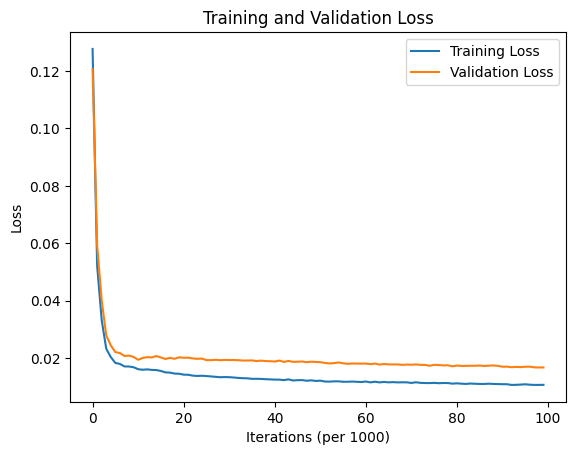

In [10]:
history_chart(train_loss_history, val_loss_history)

In [11]:
get_confusion_matrix(ZMAD_model, test_x, test_y)


============================== ZMAD ANN Model Test Results ==============================

Model Accuracy:
 0.9561904761904761

Confusion matrix:
 [[497  26]
 [ 20 507]]

Classification report:
               precision    recall  f1-score   support

           0       0.96      0.95      0.96       523
           1       0.95      0.96      0.96       527

    accuracy                           0.96      1050
   macro avg       0.96      0.96      0.96      1050
weighted avg       0.96      0.96      0.96      1050




(0.9561904761904761, np.float64(0.9561880917824314))

In [12]:
ZENA_model = ZENA(30, 128, 32, 0.03, 100000, 5000, 1e-4, 'xavier', 0.9)
train_loss_history, val_loss_history = ZENA_model.fit(train_x, train_y, val_x, val_y)

Iteration: 0
Training Loss: 8.761359013371221
Validation Loss: 10.314009921848507
Iteration: 1000
Training Loss: 0.13616896885238203
Validation Loss: 0.15293000308336405
Iteration: 2000
Training Loss: 0.11232797402224787
Validation Loss: 0.1338468935326252
Iteration: 3000
Training Loss: 0.09274420935443412
Validation Loss: 0.12984494632528704
Iteration: 4000
Training Loss: 0.07892278484377767
Validation Loss: 0.12372938677949305
Iteration: 5000
Training Loss: 0.07759816335426262
Validation Loss: 0.13791773911259433
Iteration: 6000
Training Loss: 0.07207662252044106
Validation Loss: 0.1339816616094928
Iteration: 7000
Training Loss: 0.07066315535976195
Validation Loss: 0.13394019837687177
Iteration: 8000
Training Loss: 0.06186278370883382
Validation Loss: 0.1263343232361484
Iteration: 9000
Training Loss: 0.07416063530148392
Validation Loss: 0.13577469262407332
Early stopping at iteration 9000


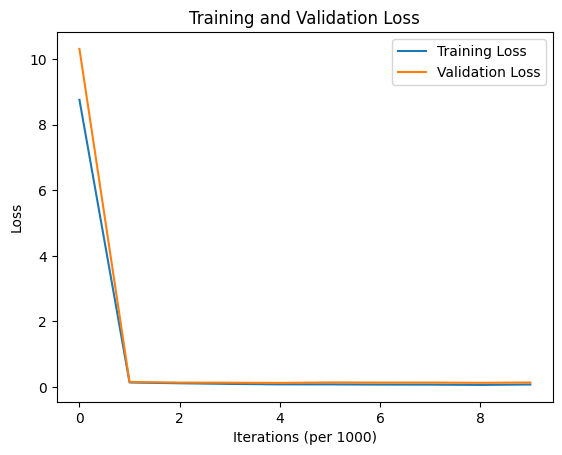

In [13]:
history_chart(train_loss_history, val_loss_history)

In [14]:
get_confusion_matrix(ZENA_model, test_x, test_y)


============================== ZMAD ANN Model Test Results ==============================

Model Accuracy:
 0.9542857142857143

Confusion matrix:
 [[519   4]
 [ 44 483]]

Classification report:
               precision    recall  f1-score   support

           0       0.92      0.99      0.96       523
           1       0.99      0.92      0.95       527

    accuracy                           0.95      1050
   macro avg       0.96      0.95      0.95      1050
weighted avg       0.96      0.95      0.95      1050




(0.9542857142857143, np.float64(0.9542259355604021))

# Test on new samples

In [15]:
ZENA_data = pd.read_csv('ZENA_data.csv')
ZENA_df = label_conversion(ZENA_data)

In [53]:
new_df = pd.concat([second_df, third_df[third_df.columns.drop(['Speed','RSSI'])]], axis=0, ignore_index=True)

In [54]:
new_X = np.array(new_df.iloc[:, :-1], dtype=int).T
new_Y = np.array(new_df.iloc[:, -1], dtype=int)

In [13]:
get_confusion_matrix(ZMAD_model, new_X, new_Y)


============================== ZMAD ANN Model Test Results ==============================

Model Accuracy:
 0.6890593510287616

Confusion matrix:
 [[14630  8882]
 [11021 29476]]

Classification report:
               precision    recall  f1-score   support

           0       0.57      0.62      0.60     23512
           1       0.77      0.73      0.75     40497

    accuracy                           0.69     64009
   macro avg       0.67      0.68      0.67     64009
weighted avg       0.70      0.69      0.69     64009




/tmp/ipykernel_34857/80554236.py:24: RuntimeWarning: overflow encountered in exp
  return 1.0 / (1.0 + np.exp(-x))


(0.6890593510287616, np.float64(0.6916063579730276))

In [16]:
get_confusion_matrix(ZENA_model, new_X, new_Y)

NameError: name 'new_X' is not defined

# 0-1. Data swap
- Can we prove the diversity of dataset?

In [71]:
new_df['Labels'].value_counts()

Labels
1    40497
0    23512
Name: count, dtype: int64

In [72]:
train_x, train_y, val_x, val_y, test_x, test_y = data_splitter(new_df)

Total data count : 64009
Labels
1    32355
0    18852
Name: count, dtype: int64
Labels
1    4112
0    2289
Name: count, dtype: int64
Labels
1    4030
0    2371
Name: count, dtype: int64
****************************************************************************************************


In [16]:
ZMAD_swap = ZMAD()
train_loss_history, val_loss_history = ZMAD_swap.fit(train_x, train_y, val_x, val_y)

Iteration: 0
Training Loss: 0.12271155000608475
Validation Loss: 0.11606638289219864
Iteration: 1000
Training Loss: 0.03701609052434977
Validation Loss: 0.03866514704173147
Iteration: 2000
Training Loss: 0.033606077761202474
Validation Loss: 0.0357312379175493
Iteration: 3000
Training Loss: 0.03211354789011496
Validation Loss: 0.034215667009706595
Iteration: 4000
Training Loss: 0.03137800300263262
Validation Loss: 0.03371497337024284
Iteration: 5000
Training Loss: 0.03095540784420939
Validation Loss: 0.03322522854179411
Iteration: 6000
Training Loss: 0.03013062585337976
Validation Loss: 0.03241982513845552
Iteration: 7000
Training Loss: 0.029846484436540973
Validation Loss: 0.032135952245043585
Iteration: 8000
Training Loss: 0.029662770791663965
Validation Loss: 0.031872719921369495
Iteration: 9000
Training Loss: 0.02951745926054896
Validation Loss: 0.03167836422206649
Iteration: 10000
Training Loss: 0.02932624960648091
Validation Loss: 0.03152669783032326
Iteration: 11000
Training Los

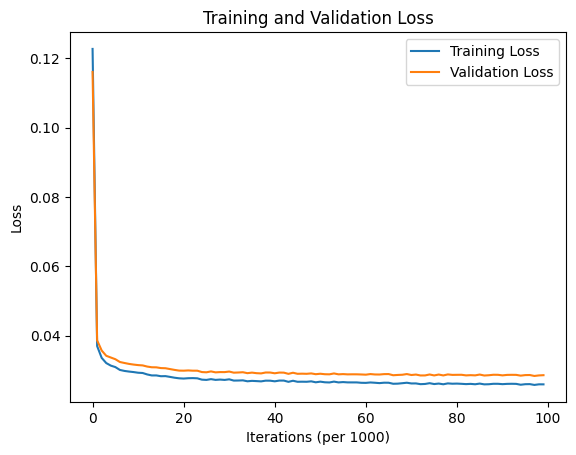

In [17]:
history_chart(train_loss_history, val_loss_history)

In [60]:
old_X = np.array(data_df.iloc[:, :-1], dtype=int).T
old_Y = np.array(data_df.iloc[:, -1], dtype=int)

In [19]:
get_confusion_matrix(ZMAD_swap, test_x, test_y)


============================== ZMAD ANN Model Test Results ==============================

Model Accuracy:
 0.934541477894079

Confusion matrix:
 [[2157  214]
 [ 205 3825]]

Classification report:
               precision    recall  f1-score   support

           0       0.91      0.91      0.91      2371
           1       0.95      0.95      0.95      4030

    accuracy                           0.93      6401
   macro avg       0.93      0.93      0.93      6401
weighted avg       0.93      0.93      0.93      6401




(0.934541477894079, np.float64(0.9345157473759501))

In [20]:
get_confusion_matrix(ZMAD_swap, old_X, old_Y)


============================== ZMAD ANN Model Test Results ==============================

Model Accuracy:
 0.6512004573170732

Confusion matrix:
 [[5007  318]
 [3343 1828]]

Classification report:
               precision    recall  f1-score   support

           0       0.60      0.94      0.73      5325
           1       0.85      0.35      0.50      5171

    accuracy                           0.65     10496
   macro avg       0.73      0.65      0.62     10496
weighted avg       0.72      0.65      0.62     10496




(0.6512004573170732, np.float64(0.6176783413838861))

In [78]:
ZENA_swap = ZENA(30, 128, 32, 0.03, 100000, 5000, 1e-4, 'xavier', 0.9)
train_loss_history, val_loss_history = ZENA_swap.fit(train_x, train_y, val_x, val_y)

Iteration: 0
Training Loss: 6.949966944393303
Validation Loss: 5.366053065608039
Iteration: 1000
Training Loss: 0.2167807725230547
Validation Loss: 0.2337079409615589
Iteration: 2000
Training Loss: 0.19429624195266873
Validation Loss: 0.21390344964955416
Iteration: 3000
Training Loss: 0.1790478593136011
Validation Loss: 0.19942595162948124
Iteration: 4000
Training Loss: 0.1702019044945926
Validation Loss: 0.1924237311710839
Iteration: 5000
Training Loss: 0.16442719910058354
Validation Loss: 0.1878560149540442
Iteration: 6000
Training Loss: 0.15964548748650878
Validation Loss: 0.18342796606102563
Iteration: 7000
Training Loss: 0.1558306395711623
Validation Loss: 0.17989067435809655
Iteration: 8000
Training Loss: 0.15251152459621542
Validation Loss: 0.17740814253218737
Iteration: 9000
Training Loss: 0.15004228919536833
Validation Loss: 0.17595443578195344
Iteration: 10000
Training Loss: 0.14816368091376983
Validation Loss: 0.174973517836826
Iteration: 11000
Training Loss: 0.1465544488409

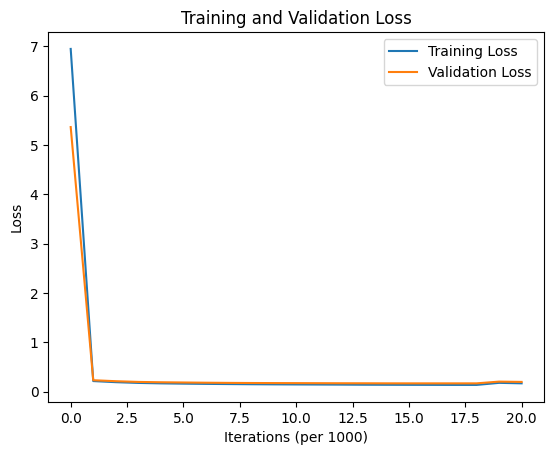

In [79]:
history_chart(train_loss_history, val_loss_history)

In [82]:
get_confusion_matrix(ZENA_swap, test_x, test_y)


============================== ZMAD ANN Model Test Results ==============================

Model Accuracy:
 0.9292298078425246

Confusion matrix:
 [[2049  322]
 [ 131 3899]]

Classification report:
               precision    recall  f1-score   support

           0       0.94      0.86      0.90      2371
           1       0.92      0.97      0.95      4030

    accuracy                           0.93      6401
   macro avg       0.93      0.92      0.92      6401
weighted avg       0.93      0.93      0.93      6401




(0.9292298078425246, np.float64(0.9285638571914542))

In [83]:
get_confusion_matrix(ZENA_swap, old_X, old_Y)


============================== ZMAD ANN Model Test Results ==============================

Model Accuracy:
 0.7229420731707317

Confusion matrix:
 [[4636  689]
 [2219 2952]]

Classification report:
               precision    recall  f1-score   support

           0       0.68      0.87      0.76      5325
           1       0.81      0.57      0.67      5171

    accuracy                           0.72     10496
   macro avg       0.74      0.72      0.72     10496
weighted avg       0.74      0.72      0.72     10496




(0.7229420731707317, np.float64(0.7162911440224462))

## 0-2. ZMAD on combined dataset
- Seems like two datasets do not show much in common.
- The model trained on either of the dataset does not show high performance on the other.
- However, I was able to observe performance drop on the second dataset (92%).
- This time, let's calculate ZMAD model's performance on the combined set.

In [63]:
data_df

,SRC,P1,P2,LEN,DST,CMDCL,CMD,Val1,Val2,Val3,...,Val15,Val16,Val17,Val18,Val19,Val20,Val21,Val22,Val23,Labels
0,0,129,11,10,1,197,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
1,1,129,11,13,1,32,1,255,213,0,...,0,0,0,0,0,0,0,0,0,1
2,1,129,11,10,1,78,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
3,1,129,11,20,1,113,5,7,255,0,...,0,0,0,0,0,0,0,0,0,1
4,1,129,11,10,1,77,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10491,9,1,12,30,255,1,1,211,156,1,...,39,44,43,122,132,0,0,0,0,0
10492,9,1,15,30,255,1,1,211,156,1,...,39,44,43,122,135,0,0,0,0,0
10493,9,1,3,30,255,1,1,211,156,1,...,39,44,43,122,139,0,0,0,0,0
10494,9,1,6,30,255,1,1,211,156,1,...,39,44,43,122,142,0,0,0,0,0


In [64]:
new_df

,SRC,P1,P2,LEN,DST,CMDCL,CMD,Val1,Val2,Val3,...,Val15,Val16,Val17,Val18,Val19,Val20,Val21,Val22,Val23,Labels
0,14,65,1,13,1,32,1,255,133,0,...,0,0,0,0,0,0,0,0,0,1
1,1,3,1,10,14,30,-1,0,0,0,...,0,0,0,0,0,0,0,0,0,1
2,14,65,2,20,1,113,5,0,0,0,...,0,0,0,0,0,0,0,0,0,1
3,1,3,2,10,14,29,-1,0,0,0,...,0,0,0,0,0,0,0,0,0,1
4,13,65,1,13,1,32,1,255,134,0,...,0,0,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
64004,200,65,1,21,10,37,1,115,61,144,...,0,0,0,0,0,0,0,0,0,0
64005,10,3,1,10,200,211,-1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
64006,200,65,1,21,10,37,1,115,61,144,...,0,0,0,0,0,0,0,0,0,0
64007,10,3,1,10,200,211,-1,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [65]:
combined_df = pd.concat([data_df, new_df], axis=0, ignore_index=True)
combined_df

,SRC,P1,P2,LEN,DST,CMDCL,CMD,Val1,Val2,Val3,...,Val15,Val16,Val17,Val18,Val19,Val20,Val21,Val22,Val23,Labels
0,0,129,11,10,1,197,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
1,1,129,11,13,1,32,1,255,213,0,...,0,0,0,0,0,0,0,0,0,1
2,1,129,11,10,1,78,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
3,1,129,11,20,1,113,5,7,255,0,...,0,0,0,0,0,0,0,0,0,1
4,1,129,11,10,1,77,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
74500,200,65,1,21,10,37,1,115,61,144,...,0,0,0,0,0,0,0,0,0,0
74501,10,3,1,10,200,211,-1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
74502,200,65,1,21,10,37,1,115,61,144,...,0,0,0,0,0,0,0,0,0,0
74503,10,3,1,10,200,211,-1,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [66]:
train_x, train_y, val_x, val_y, test_x, test_y = data_splitter(combined_df)

Total data count : 74505
Labels
1    36478
0    23126
Name: count, dtype: int64
Labels
1    4584
0    2866
Name: count, dtype: int64
Labels
1    4606
0    2845
Name: count, dtype: int64
****************************************************************************************************


In [25]:
ZMAD_combined = ZMAD()

In [26]:
train_loss_history, val_loss_history = ZMAD_combined.fit(train_x, train_y, val_x, val_y)

Iteration: 0
Training Loss: 0.12720662448537595
Validation Loss: 0.11931776251839368
Iteration: 1000
Training Loss: 0.042386443193511154
Validation Loss: 0.04338552629037938
Iteration: 2000
Training Loss: 0.03772397126379019
Validation Loss: 0.038987848557056004
Iteration: 3000
Training Loss: 0.035208972514754674
Validation Loss: 0.03632159878156001
Iteration: 4000
Training Loss: 0.033740455166215086
Validation Loss: 0.03474421376896321
Iteration: 5000
Training Loss: 0.03280261854090548
Validation Loss: 0.033707843115343056
Iteration: 6000
Training Loss: 0.03205425857736545
Validation Loss: 0.03283898439476469
Iteration: 7000
Training Loss: 0.03144785233590467
Validation Loss: 0.03216936346910726
Iteration: 8000
Training Loss: 0.031008317314210738
Validation Loss: 0.03166215380815384
Iteration: 9000
Training Loss: 0.030616227081106298
Validation Loss: 0.03131347071309027
Iteration: 10000
Training Loss: 0.03031844156010172
Validation Loss: 0.031066221785766002
Iteration: 11000
Training 

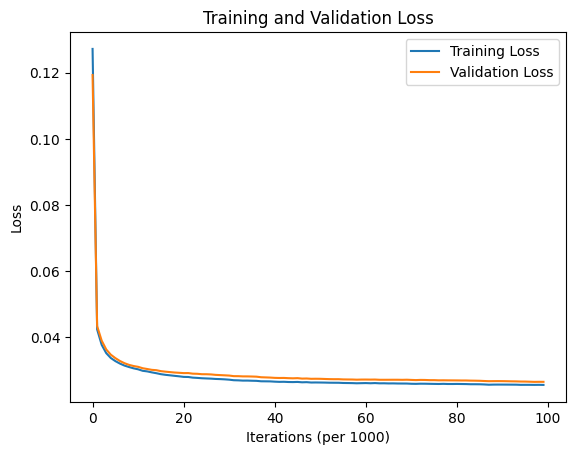

In [27]:
history_chart(train_loss_history, val_loss_history)

In [28]:
get_confusion_matrix(ZMAD_combined, test_x, test_y)


============================== ZMAD ANN Model Test Results ==============================

Model Accuracy:
 0.9286001878942424

Confusion matrix:
 [[2463  382]
 [ 150 4456]]

Classification report:
               precision    recall  f1-score   support

           0       0.94      0.87      0.90      2845
           1       0.92      0.97      0.94      4606

    accuracy                           0.93      7451
   macro avg       0.93      0.92      0.92      7451
weighted avg       0.93      0.93      0.93      7451




(0.9286001878942424, np.float64(0.9279597119203424))

In [67]:
ZENA_combined = ZENA(30, 128, 32, 0.03, 100000, 5000, 1e-4, 'xavier', 0.9)
train_loss_history, val_loss_history = ZENA_combined.fit(train_x, train_y, val_x, val_y)

Iteration: 0
Training Loss: 3.904858023206238
Validation Loss: 2.2018163354321914
Iteration: 1000
Training Loss: 0.2106761556931133
Validation Loss: 0.23846132652308044
Iteration: 2000
Training Loss: 0.18699929087991965
Validation Loss: 0.20817981019020346
Iteration: 3000
Training Loss: 0.16969511304223941
Validation Loss: 0.18751849654434302
Iteration: 4000
Training Loss: 0.15555211941406502
Validation Loss: 0.17326722983964205
Iteration: 5000
Training Loss: 0.15060633591961256
Validation Loss: 0.16876348624588394
Iteration: 6000
Training Loss: 0.14519772588028668
Validation Loss: 0.16431943849910877
Iteration: 7000
Training Loss: 0.14133998998748845
Validation Loss: 0.16106203426860904
Iteration: 8000
Training Loss: 0.13903635363647848
Validation Loss: 0.16010718718962103
Iteration: 9000
Training Loss: 0.14952079330852797
Validation Loss: 0.16237847616274953
Iteration: 10000
Training Loss: 0.1402163402646385
Validation Loss: 0.15833287062612014
Iteration: 11000
Training Loss: 0.13486

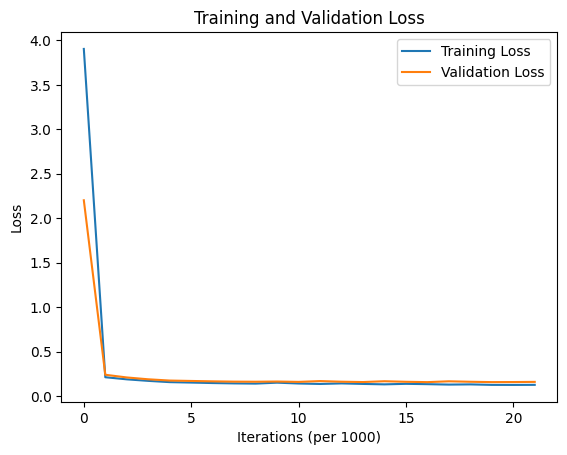

In [68]:
history_chart(train_loss_history, val_loss_history)

In [69]:
get_confusion_matrix(ZENA_combined, test_x, test_y)


============================== ZMAD ANN Model Test Results ==============================

Model Accuracy:
 0.948865924037042

Confusion matrix:
 [[2577  268]
 [ 113 4493]]

Classification report:
               precision    recall  f1-score   support

           0       0.96      0.91      0.93      2845
           1       0.94      0.98      0.96      4606

    accuracy                           0.95      7451
   macro avg       0.95      0.94      0.95      7451
weighted avg       0.95      0.95      0.95      7451




(0.948865924037042, np.float64(0.9485730239709046))

In [31]:
ZMAD_model.save_params("params/ZMAD_original.pkl")
ZMAD_swap.save_params("params/ZMAD_swap.pkl")
ZMAD_combined.save_params("params/ZMAD_combined.pkl")

Parameters saved to params/ZMAD_original.pkl
Parameters saved to params/ZMAD_swap.pkl


In [84]:
ZENA_model.save_params("params/ZENA_original.pkl")
ZENA_swap.save_params("params/ZENA_swap.pkl")
ZENA_combined.save_params("params/ZENA_combined.pkl")

Parameters saved to params/ZENA_original.pkl
Parameters saved to params/ZENA_swap.pkl
Parameters saved to params/ZENA_combined.pkl


## 0-3. Dataset Distribution

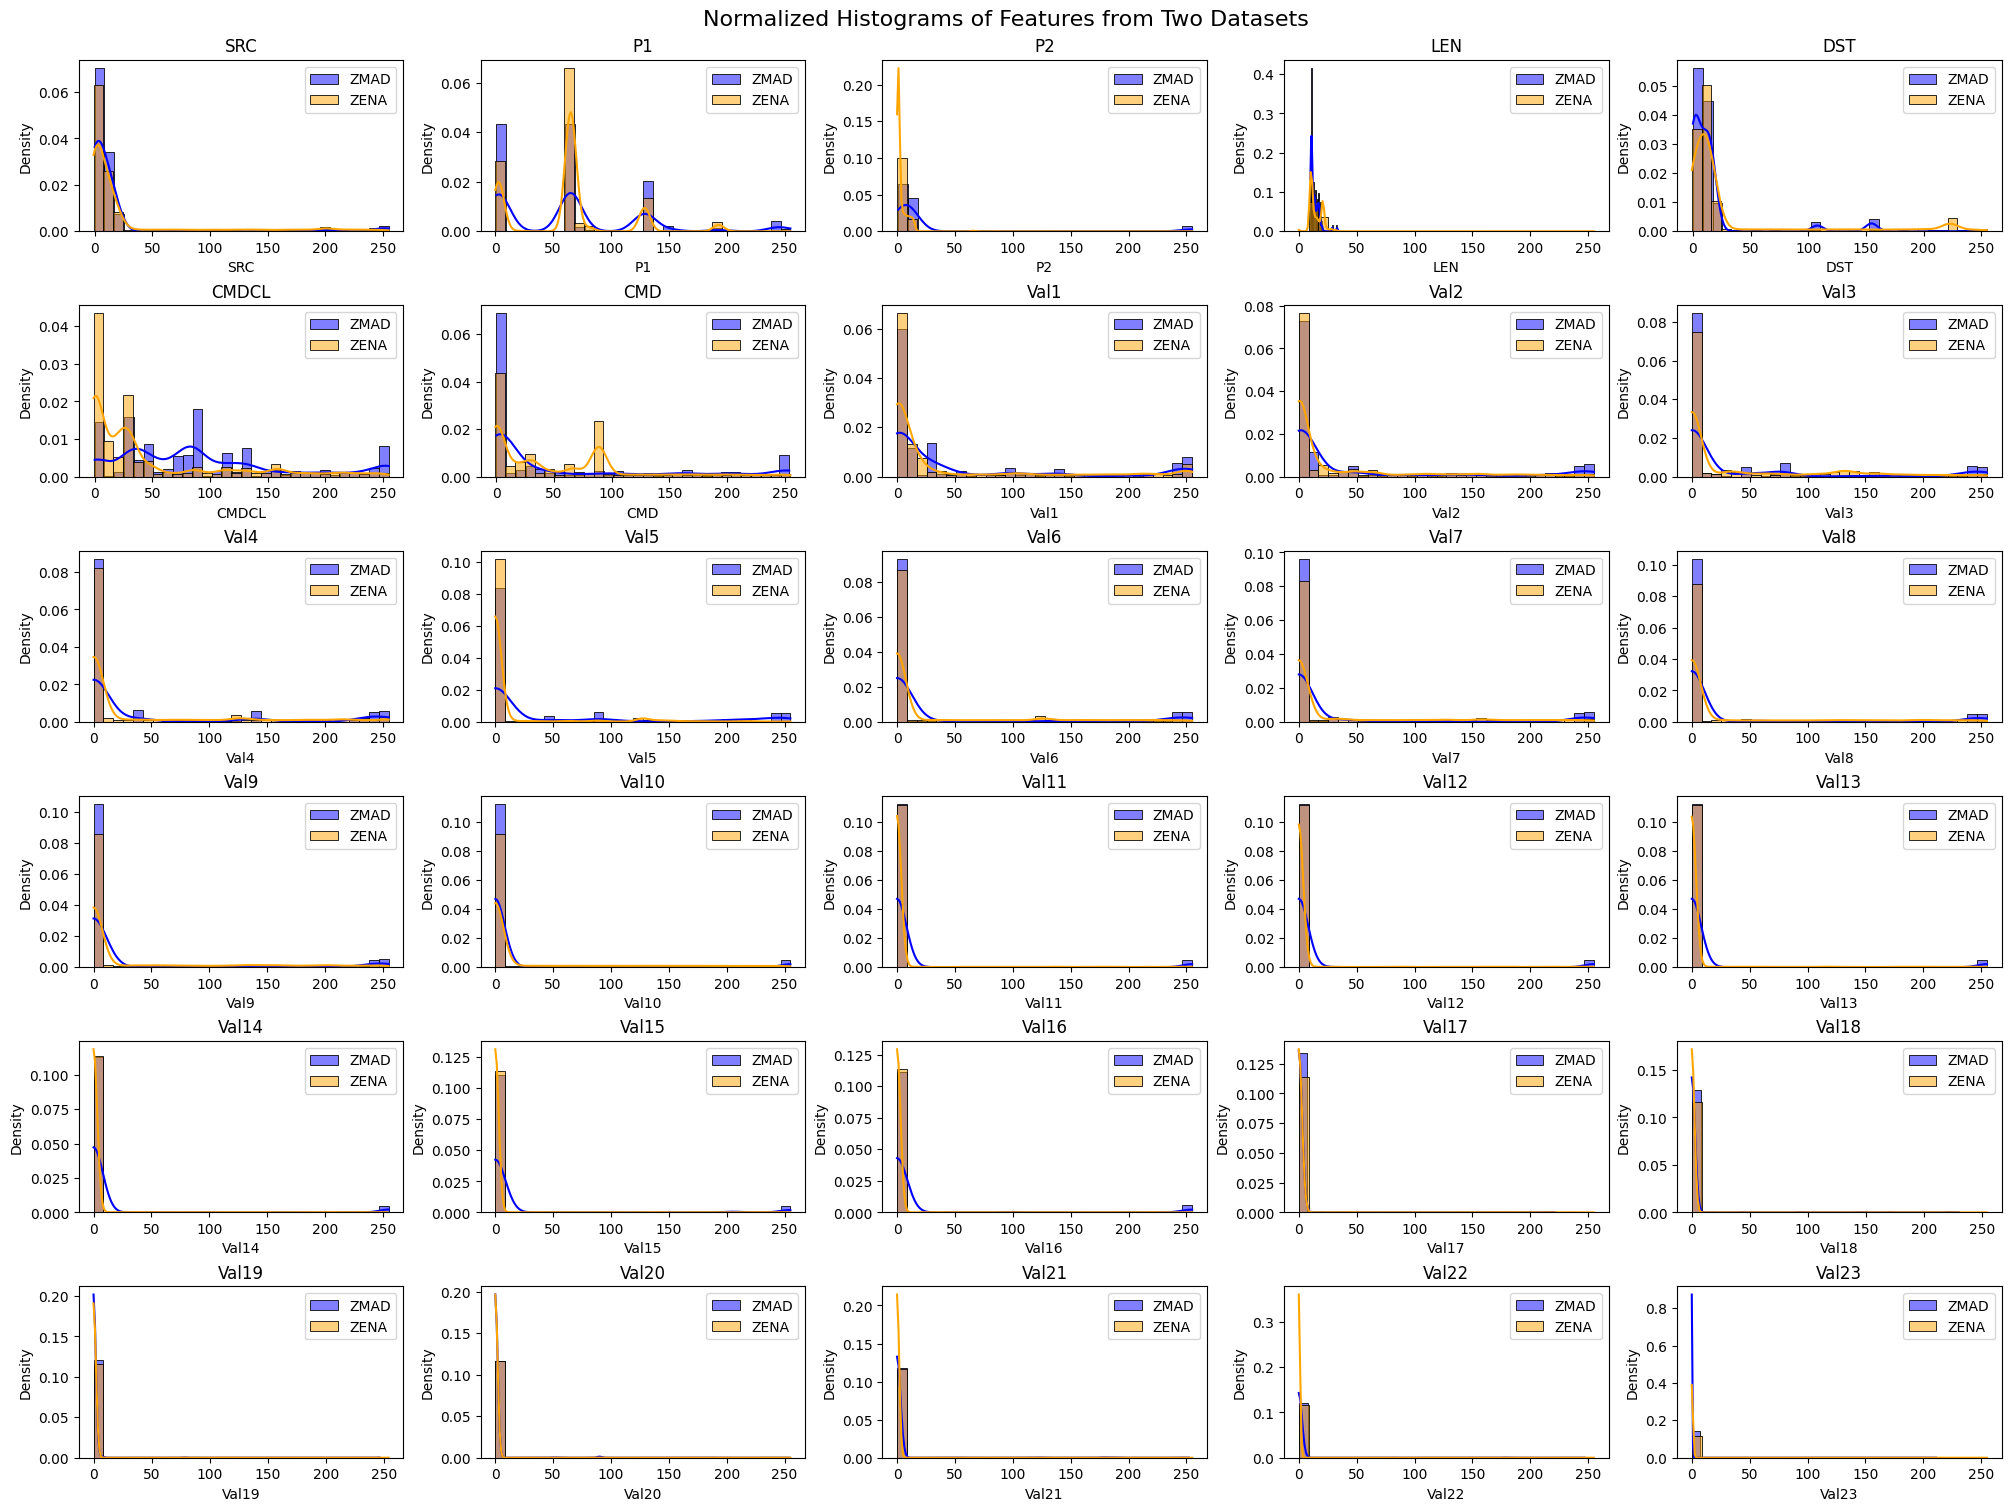

In [29]:
# Plotting all features in one figure with normalized histograms
fig, axes = plt.subplots(nrows=6, ncols=5, figsize=(20, 15), constrained_layout=True)
axes = axes.flatten()

for i, column in enumerate(data_df.columns[:-1]):
    ax = axes[i]
    sns.histplot(data_df[column], bins=30, color='blue', label='ZMAD', stat='density', ax=ax, kde=True)
    sns.histplot(new_df[column], bins=30, color='orange', label='ZENA', stat='density', ax=ax, kde=True)
    ax.set_title(f'{column}')
    ax.legend()

plt.suptitle('Normalized Histograms of Features from Two Datasets', fontsize=16)
plt.show()

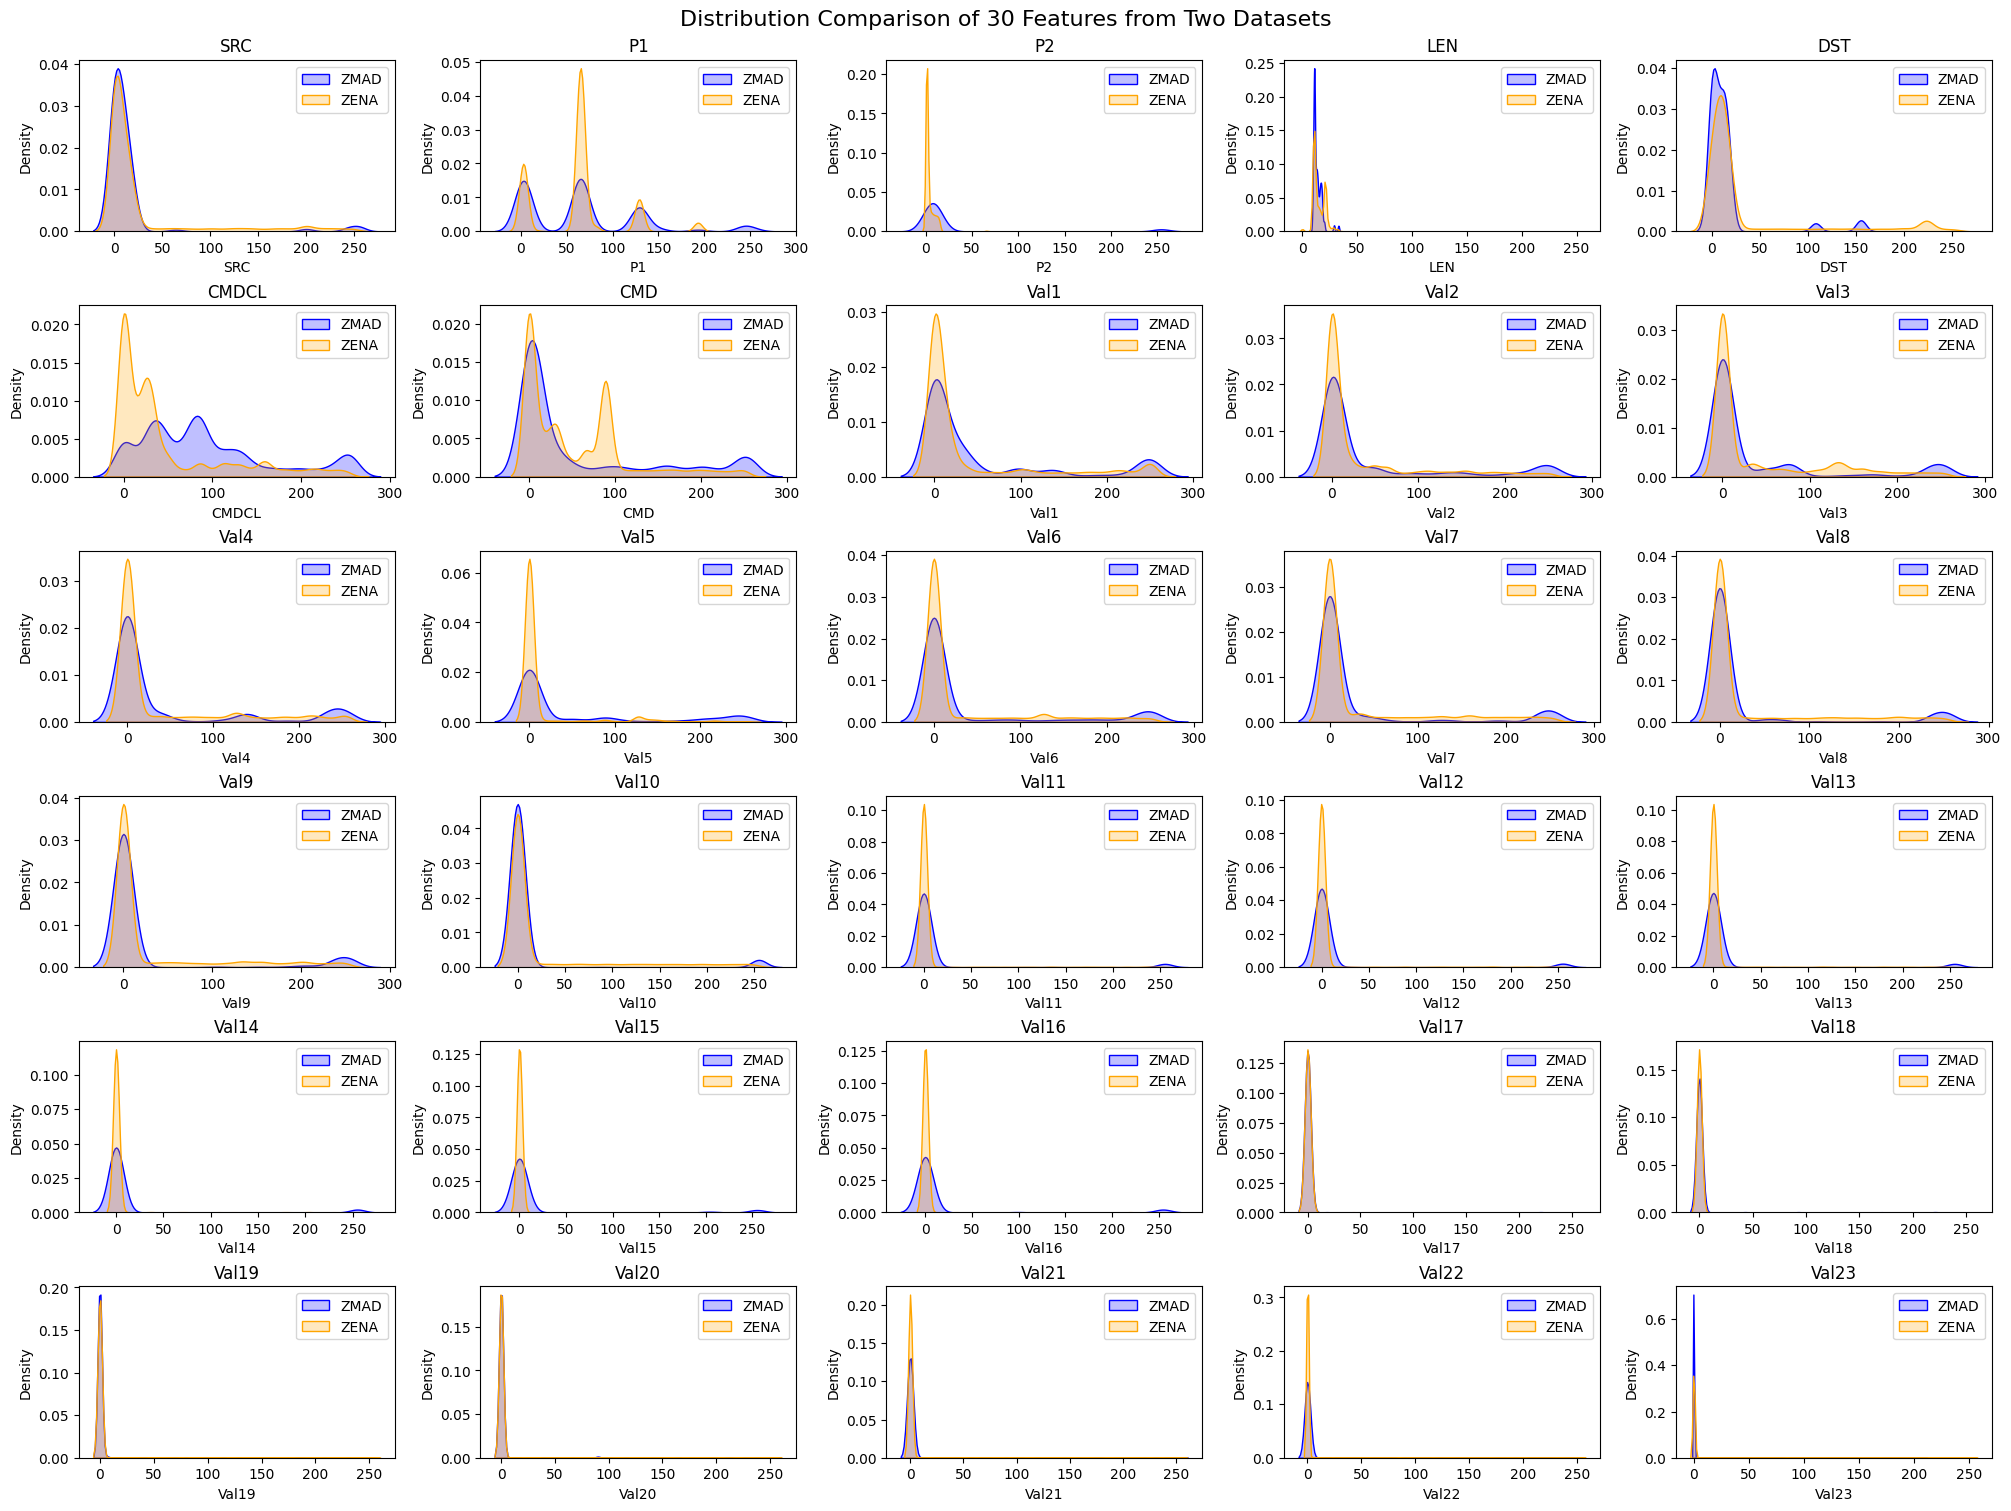

In [92]:
fig, axes = plt.subplots(nrows=6, ncols=5, figsize=(20, 15), constrained_layout=True)
axes = axes.flatten()

# Plot density plots for each feature
for i, column in enumerate(data_df.columns[:-1]):
    ax = axes[i]
    sns.kdeplot(data_df[column], color='blue', label='ZMAD', fill=True, ax=ax)
    sns.kdeplot(new_df[column], color='orange', label='ZENA', fill=True, ax=ax)
    ax.set_title(column)
    ax.legend()

plt.suptitle('Distribution Comparison of 30 Features from Two Datasets', fontsize=16)
plt.show()

# 1. Data Load

In [4]:
# DF Load
first_df_og = pd.read_csv('packet_data_final.csv')
second_df_og = pd.read_csv('clean_data.csv')
third_df_og = pd.read_csv('cleaned_data_2.csv')

In [5]:
# Label Conversion
def label_conversion(df):
    df.loc[df['Labels'] == 'abnormal', 'Labels'] = 1
    df.loc[df['Labels'] == 'normal', 'Labels'] = 0
    df['Labels'].astype(int)
    return df

# Data Split
def data_splitter(data, train_ratio=0.8, val_ratio=0.1, test_ratio=0.1, random_seed=42):

    if train_ratio+val_ratio+test_ratio != 1 :
        print(f"Ratio setting is not correct : {train_ratio}+{val_ratio}+{test_ratio} != 1")

    if random_seed is not None:
        np.random.seed(random_seed)

    print(f"Total data count : {len(data)}")
    
    # Mixing up indices
    shuffled_indices = np.random.permutation(data.index)

    # Set the split point
    train_split_point = int(len(data)*train_ratio)
    validation_split_point = int(len(data)*(train_ratio+val_ratio))

    # Separate indices
    train_indices = shuffled_indices[:train_split_point]
    val_indices = shuffled_indices[train_split_point:validation_split_point]
    test_indices = shuffled_indices[validation_split_point:]

    # Assign df data according to the indices
    train_data = data.loc[train_indices].reset_index(drop=True)
    val_data = data.loc[val_indices].reset_index(drop=True)
    test_data = data.loc[test_indices].reset_index(drop=True)

    print(train_data['Labels'].value_counts())
    print(val_data['Labels'].value_counts())
    print(test_data['Labels'].value_counts())
    print('*'*100)
    
    # Split X, Y
    train_X = np.array(train_data.iloc[:, :-1], dtype=int).T
    train_Y = np.array(train_data.iloc[:, -1], dtype=int)
    val_X = np.array(val_data.iloc[:, :-1], dtype=int).T
    val_Y = np.array(val_data.iloc[:, -1], dtype=int)
    test_X = np.array(test_data.iloc[:, :-1], dtype=int).T
    test_Y = np.array(test_data.iloc[:, -1], dtype=int)

    return train_X, train_Y, val_X, val_Y, test_X, test_Y

In [6]:
first_df = label_conversion(first_df_og)
second_df = label_conversion(second_df_og)
third_df = label_conversion(third_df_og)

In [7]:
train_x, train_y, val_x, val_y, test_x, test_y = data_splitter(third_df)

Total data count : 27825
Labels
1    12964
0     9296
Name: count, dtype: int64
Labels
1    1562
0    1220
Name: count, dtype: int64
Labels
1    1598
0    1185
Name: count, dtype: int64
****************************************************************************************************


# 2. Visualization and Feature Map

In [8]:
# Call PCA visualization
def PCA_visualization(df):
    x = df.iloc[:, :-1]
    y = df.iloc[:, -1]
    scaler = StandardScaler()
    scaled_x = scaler.fit_transform(x)
    
    pca_model = PCA(n_components=2)
    pca_result = pca_model.fit_transform(scaled_x)
    pca_df = pd.DataFrame(pca_result, columns=['PCA1', 'PCA2'])
    pca_df['Labels'] = y.values

    plt.figure(figsize=(10, 7))
    for label in pca_df['Labels'].unique():
        subset = pca_df[pca_df['Labels'] == label]
        plt.scatter(subset['PCA1'], subset['PCA2'], label=f'Label {label}')
    plt.title('PCA of Dataset')
    plt.xlabel('PCA1')
    plt.ylabel('PCA2')
    plt.legend()
    plt.show()
    return

# Call TSNE visualization
def TSNE_visualization(df):
    x = df.iloc[:, :-1]
    y = df.iloc[:, -1]
    scaler = StandardScaler()
    scaled_x = scaler.fit_transform(x)

    tsne = TSNE(n_components=2, random_state=42)
    tsne_result = tsne.fit_transform(scaled_x)
    
    # t-SNE 결과를 데이터프레임으로 생성
    tsne_df = pd.DataFrame(tsne_result, columns=['TSNE1', 'TSNE2'])
    tsne_df['Labels'] = y.values
    
    # 라벨에 따른 t-SNE 시각화
    plt.figure(figsize=(10, 7))
    for label in tsne_df['Labels'].unique():
        subset = tsne_df[tsne_df['Labels'] == label]
        plt.scatter(subset['TSNE1'], subset['TSNE2'], label=f'Label {label}')
    plt.title('t-SNE of Dataset')
    plt.xlabel('TSNE1')
    plt.ylabel('TSNE2')
    plt.legend()
    plt.show()
    return
    
# Draw Feature maps
def feature_map(df):
    x = df.iloc[:, :-1]
    y = df.iloc[:, -1].astype(int)

    rf_model = RandomForestClassifier(random_state=42)
    rf_model.fit(x, y)
    
    importances = rf_model.feature_importances_
    indices = np.argsort(importances)[::-1]
    
    # Visualize feature importance
    plt.figure(figsize=(12, 8))
    plt.title("Feature Importances")
    plt.bar(range(x.shape[1]), importances[indices], align="center")
    plt.xticks(range(x.shape[1]), [x.columns[i] for i in indices], rotation=90)
    plt.xlim([-1, x.shape[1]])
    plt.show()
    return

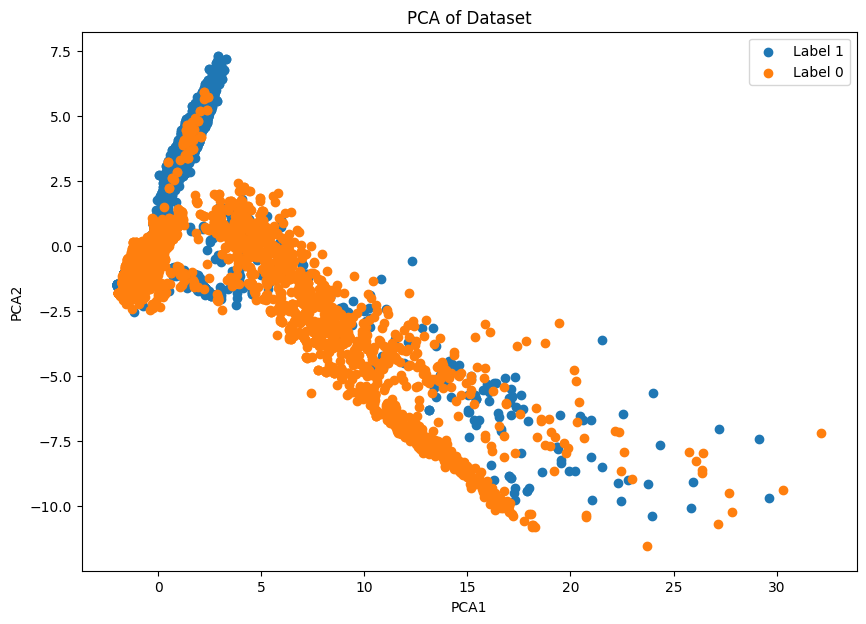

In [9]:
PCA_visualization(third_df)

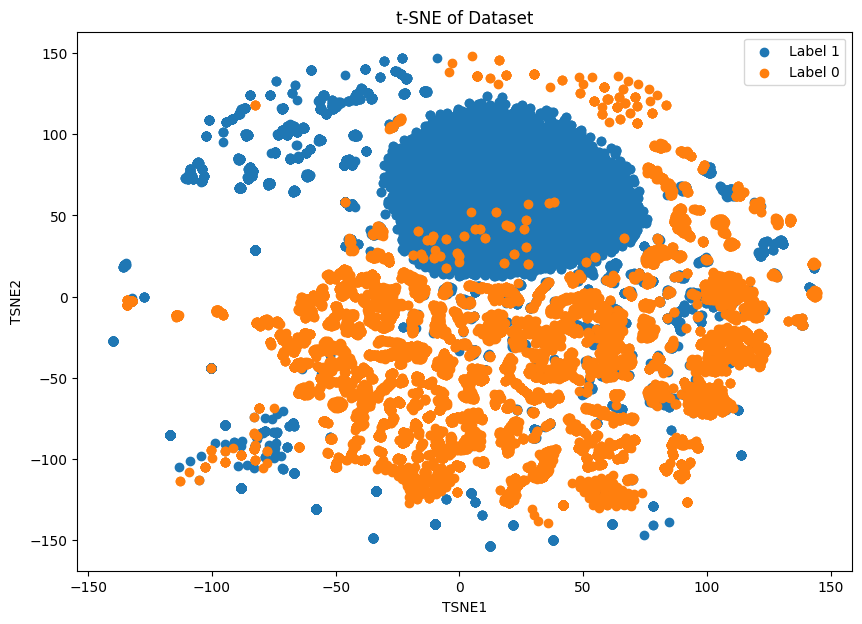

In [10]:
TSNE_visualization(third_df)

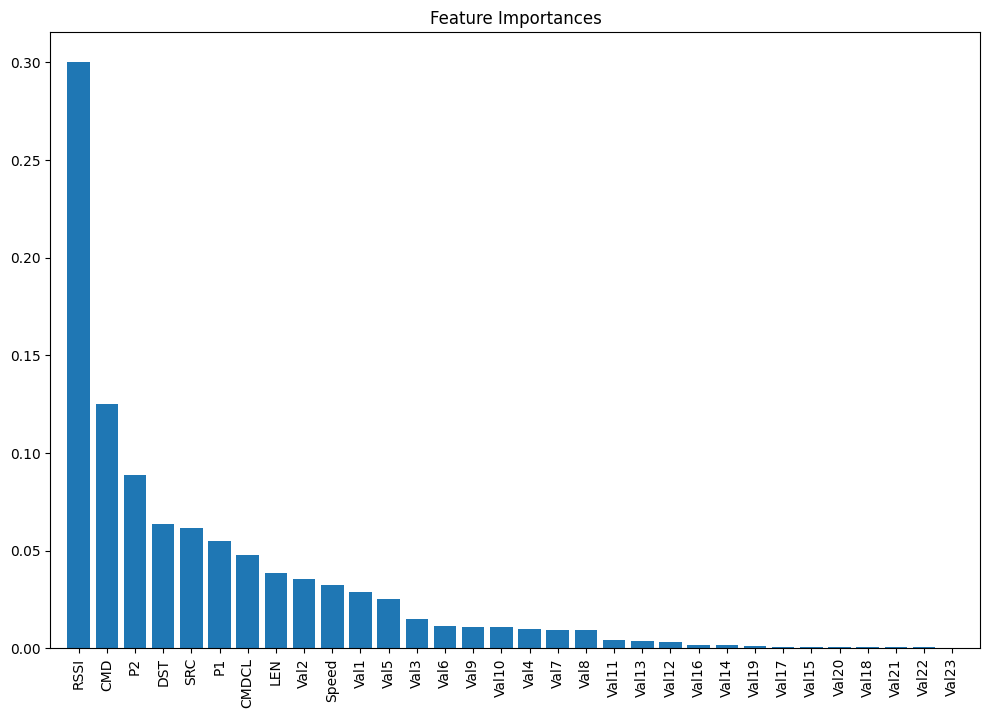

In [11]:
feature_map(third_df)

# 3. Model Architecture

## 3-1. Single-Layer

In [ ]:
class SingleLayerPerceptron:
    def __init__(self, input_size, hidden_size, learning_rate=0.01, iterations=10000, early_stopping_rounds=100, tolerance=1e-4, init_method='he'):
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.output_size = 1
        self.learning_rate = learning_rate
        self.iterations = iterations
        self.early_stopping_rounds = early_stopping_rounds
        self.tolerance = tolerance
        self.init_method = init_method
        self.W1, self.b1, self.W2, self.b2 = self.init_params()

    def init_params(self):
        if self.init_method == 'zero':
            W1 = np.zeros((self.hidden_size, self.input_size))
            b1 = np.zeros((self.hidden_size, 1))
            W2 = np.zeros((self.output_size, self.hidden_size))
            b2 = np.zeros((self.output_size, 1))
        elif self.init_method == 'random':
            W1 = np.random.randn(self.hidden_size, self.input_size) * 0.01
            b1 = np.random.randn(self.hidden_size, 1) * 0.01    
            W2 = np.random.randn(self.output_size, self.hidden_size) * 0.01
            b2 = np.random.randn(self.output_size, 1) * 0.01
        elif self.init_method == 'he':
            W1 = np.random.randn(self.hidden_size, self.input_size) * np.sqrt(2. / self.input_size)
            b1 = np.random.randn(self.hidden_size, 1) * np.sqrt(2. / self.hidden_size)
            W2 = np.random.randn(self.output_size, self.hidden_size) * np.sqrt(2. / self.hidden_size)
            b2 = np.random.randn(self.output_size, 1) * np.sqrt(2. / self.output_size)
        elif self.init_method == 'xavier':
            W1 = np.random.randn(self.hidden_size, self.input_size) * np.sqrt(1. / self.input_size)
            b1 = np.random.randn(self.hidden_size, 1) * np.sqrt(1. / self.hidden_size)
            W2 = np.random.randn(self.output_size, self.hidden_size) * np.sqrt(1. / self.hidden_size)
            b2 = np.random.randn(self.output_size, 1) * np.sqrt(1. / self.output_size)
        else:
            raise ValueError(f"Unknown initialization method: {self.init_method}")
        return W1, b1, W2, b2

    @staticmethod
    def ReLU(Z):
        return np.maximum(Z, 0)

    @staticmethod
    def softmax(Z):
        A = np.exp(Z) / np.sum(np.exp(Z), axis=0)
        return A

    @staticmethod
    def sigmoid(x):
        return 1.0 / (1.0 + np.exp(-x))
    
    def forward_prop(self, X):
        Z1 = self.W1.dot(X) + self.b1
        A1 = self.ReLU(Z1)
        Z2 = self.W2.dot(A1) + self.b2
        A2 = self.sigmoid(Z2)
        return Z1, A1, Z2, A2

    @staticmethod
    def ReLU_deriv(Z):
        return Z > 0

    def compute_loss(self, A2, Y):
        m = Y.shape[0]
        epsilon = 1e-10  # 작은 값 추가하여 로그 0 방지
        log_probs = -Y * np.log(A2 + epsilon) - (1 - Y) * np.log(1 - A2 + epsilon)
        loss = np.sum(log_probs) / m
        return loss
    
    def backward_prop(self, Z1, A1, Z2, A2, X, Y):
        m = X.shape[1]
        dZ2 = A2 - Y
        dW2 = 1 / m * dZ2.dot(A1.T)
        db2 = 1 / m * np.sum(dZ2, axis=1, keepdims=True)
        dZ1 = self.W2.T.dot(dZ2) * self.ReLU_deriv(Z1)
        dW1 = 1 / m * dZ1.dot(X.T)
        db1 = 1 / m * np.sum(dZ1, axis=1, keepdims=True)
        return dW1, db1, dW2, db2

    def update_params(self, dW1, db1, dW2, db2):
        self.W1 -= self.learning_rate * dW1
        self.b1 -= self.learning_rate * db1
        self.W2 -= self.learning_rate * dW2
        self.b2 -= self.learning_rate * db2

    @staticmethod
    def get_predictions(A2):
        return (A2 > 0.5).astype(int)
    
    @staticmethod
    def get_accuracy(predictions, Y):
        return np.sum(predictions == Y) / Y.size

    @staticmethod
    def get_f1_score(predictions, Y):
        return f1_score(Y.flatten(), predictions.flatten())
        
    def fit(self, X_train, Y_train, X_val, Y_val):
        train_loss_history = []
        val_loss_history = []
        best_loss = float('inf')
        best_iter = 0

        for i in range(self.iterations):
            Z1, A1, Z2, A2 = self.forward_prop(X_train)
            train_loss = self.compute_loss(A2, Y_train)
            dW1, db1, dW2, db2 = self.backward_prop(Z1, A1, Z2, A2, X_train, Y_train)
            self.update_params(dW1, db1, dW2, db2)

            if i % 1000 == 0:
                print(f"Iteration: {i}")
                train_loss_history.append(train_loss)
                print(f"Training Loss: {train_loss}")

                _, _, _, val_A2 = self.forward_prop(X_val)
                val_loss = self.compute_loss(val_A2, Y_val)
                val_loss_history.append(val_loss)
                print(f"Validation Loss: {val_loss}")

                if val_loss < best_loss - self.tolerance:
                    best_loss = val_loss
                    best_iter = i
                elif i - best_iter >= self.early_stopping_rounds:
                    print(f"Early stopping at iteration {i}")
                    break

        return train_loss_history, val_loss_history

    def predict(self, X):
        _, _, _, A2 = self.forward_prop(X)
        predictions = self.get_predictions(A2)
        return predictions.flatten()

    def save_params(self, file_path):
        params = {
            'W1': self.W1,
            'b1': self.b1,
            'W2': self.W2,
            'b2': self.b2
        }
        with open(file_path, 'wb') as file:
            pickle.dump(params, file)
        print(f"Parameters saved to {file_path}")

    def load_params(self, file_path):
        with open(file_path, 'rb') as file:
            params = pickle.load(file)
        self.W1 = params['W1']
        self.b1 = params['b1']
        self.W2 = params['W2']
        self.b2 = params['b2']
        print(f"Parameters loaded from {file_path}")

In [102]:
input_size = 32
hidden_size = 32
learning_rate = 0.01
iterations = 100000
early_stopping_rounds=5000
tolerance=1e-4
init_method = 'he' # pick one from 'xavier', 'he', or 'random'

In [106]:
single_model = SingleLayerPerceptron(input_size=input_size,
                                     hidden_size=hidden_size,
                                     learning_rate=learning_rate,
                                     iterations=100000,
                                     early_stopping_rounds=early_stopping_rounds,
                                     tolerance=tolerance,
                                     init_method=init_method)

In [107]:
train_loss_history, val_loss_history = single_model.fit(train_x, train_y, val_x, val_y)

Iteration: 0
Training Loss: 7.745574736764568
Validation Loss: 12.918656749837321
Iteration: 1000
Training Loss: 0.20720249654626371
Validation Loss: 0.21931366658965876
Iteration: 2000
Training Loss: 0.18597477887688524
Validation Loss: 0.20215071146583113
Iteration: 3000
Training Loss: 0.17394478845145228
Validation Loss: 0.1949365824607731
Iteration: 4000
Training Loss: 0.1659412179958612
Validation Loss: 0.19083192184221393
Iteration: 5000
Training Loss: 0.16058852032794976
Validation Loss: 0.18742716893830663
Iteration: 6000
Training Loss: 0.15615717839211216
Validation Loss: 0.1845673283283454
Iteration: 7000
Training Loss: 0.15156257052823852
Validation Loss: 0.18164106102999697
Iteration: 8000
Training Loss: 0.14789472441912271
Validation Loss: 0.17935659493995854
Iteration: 9000
Training Loss: 0.14439067895127394
Validation Loss: 0.1775289726374339
Iteration: 10000
Training Loss: 0.14074383154816889
Validation Loss: 0.17614202781753416
Iteration: 11000
Training Loss: 0.1374443

In [108]:
single_model_xav = SingleLayerPerceptron(input_size=input_size,
                                     hidden_size=hidden_size,
                                     learning_rate=learning_rate,
                                     iterations=100000,
                                     early_stopping_rounds=early_stopping_rounds,
                                     tolerance=tolerance,
                                     init_method='xavier')

In [110]:
train_loss_history_xav, val_loss_history_xav = single_model_xav.fit(train_x, train_y, val_x, val_y)

Iteration: 0
Training Loss: 0.10659222059892105
Validation Loss: 0.13156731616630185
Iteration: 1000
Training Loss: 0.10353189566602253
Validation Loss: 0.13022523115843027
Iteration: 2000
Training Loss: 0.10022615560295664
Validation Loss: 0.12803073386905753
Iteration: 3000
Training Loss: 0.09788698949151364
Validation Loss: 0.12669030574756324
Iteration: 4000
Training Loss: 0.0961595953626102
Validation Loss: 0.1267308045615822
Iteration: 5000
Training Loss: 0.09368657885420006
Validation Loss: 0.1258291325952455
Iteration: 6000
Training Loss: 0.09169951053026426
Validation Loss: 0.1247733462824596
Iteration: 7000
Training Loss: 0.08721865316474581
Validation Loss: 0.12136559954696857
Iteration: 8000
Training Loss: 0.0863723683942863
Validation Loss: 0.12269634896009286
Iteration: 9000
Training Loss: 0.08497190469008198
Validation Loss: 0.12338464734444897
Iteration: 10000
Training Loss: 0.08116356618822064
Validation Loss: 0.12232148509935656
Iteration: 11000
Training Loss: 0.07946

In [126]:
single_model_rand = SingleLayerPerceptron(input_size=input_size,
                                     hidden_size=hidden_size,
                                     learning_rate=learning_rate,
                                     iterations=100000,
                                     early_stopping_rounds=10000,
                                     tolerance=tolerance,
                                     init_method='random')

In [127]:
train_loss_history_rand, val_loss_history_rand = single_model_xav.fit(train_x, train_y, val_x, val_y)

Iteration: 0
Training Loss: 0.07265713655911986
Validation Loss: 0.12826532457766185
Iteration: 1000
Training Loss: 0.07167438457791298
Validation Loss: 0.12836631183669986
Iteration: 2000
Training Loss: 0.07134725326896017
Validation Loss: 0.1287852411650324
Iteration: 3000
Training Loss: 0.07099113425960293
Validation Loss: 0.12890508622821834
Iteration: 4000
Training Loss: 0.0698998690528995
Validation Loss: 0.12794641453966876
Iteration: 5000
Training Loss: 0.07018546112257668
Validation Loss: 0.1282955792354984
Iteration: 6000
Training Loss: 0.06926369416938707
Validation Loss: 0.12804992159740353
Iteration: 7000
Training Loss: 0.06941354979421688
Validation Loss: 0.12814897002909534
Iteration: 8000
Training Loss: 0.06844758787027039
Validation Loss: 0.1274957967332387
Iteration: 9000
Training Loss: 0.06881003796122055
Validation Loss: 0.12821724423664066
Iteration: 10000
Training Loss: 0.06843489660051318
Validation Loss: 0.1283355406541574
Iteration: 11000
Training Loss: 0.06828

## 3-2. Double Layers

In [133]:
class DoubleLayerPerceptron:
    def __init__(self, input_size, hidden_size1, hidden_size2, learning_rate=0.01, iterations=10000, early_stopping_rounds=100, tolerance=1e-4, init_method='he'):
        self.input_size = input_size
        self.hidden_size1 = hidden_size1
        self.hidden_size2 = hidden_size2
        self.output_size = 1
        self.learning_rate = learning_rate
        self.iterations = iterations
        self.early_stopping_rounds = early_stopping_rounds
        self.tolerance = tolerance
        self.init_method = init_method
        self.W1, self.b1, self.W2, self.b2, self.W3, self.b3 = self.init_params()

    def init_params(self):
        if self.init_method == 'zero':
            W1 = np.zeros((self.hidden_size1, self.input_size))
            b1 = np.zeros((self.hidden_size1, 1))
            W2 = np.zeros((self.hidden_size2, self.hidden_size1))
            b2 = np.zeros((self.hidden_size2, 1))
            W3 = np.zeros((self.output_size, self.hidden_size2))
            b3 = np.zeros((self.output_size, 1))
        elif self.init_method == 'random':
            W1 = np.random.randn(self.hidden_size1, self.input_size) * 0.01
            b1 = np.random.randn(self.hidden_size1, 1) * 0.01
            W2 = np.random.randn(self.hidden_size2, self.hidden_size1) * 0.01
            b2 = np.random.randn(self.hidden_size2, 1) * 0.01
            W3 = np.random.randn(self.output_size, self.hidden_size2) * 0.01
            b3 = np.random.randn(self.output_size, 1) * 0.01
        elif self.init_method == 'he':
            W1 = np.random.randn(self.hidden_size1, self.input_size) * np.sqrt(2. / self.input_size)
            b1 = np.random.randn(self.hidden_size1, 1) * np.sqrt(2. / self.hidden_size1)
            W2 = np.random.randn(self.hidden_size2, self.hidden_size1) * np.sqrt(2. / self.hidden_size1)
            b2 = np.random.randn(self.hidden_size2, 1) * np.sqrt(2. / self.hidden_size2)
            W3 = np.random.randn(self.output_size, self.hidden_size2) * np.sqrt(2. / self.hidden_size2)
            b3 = np.random.randn(self.output_size, 1) * np.sqrt(2. / self.output_size)
        elif self.init_method == 'xavier':
            W1 = np.random.randn(self.hidden_size1, self.input_size) * np.sqrt(1. / self.input_size)
            b1 = np.random.randn(self.hidden_size1, 1) * np.sqrt(1. / self.hidden_size1)
            W2 = np.random.randn(self.hidden_size2, self.hidden_size1) * np.sqrt(1. / self.hidden_size1)
            b2 = np.random.randn(self.hidden_size2, 1) * np.sqrt(1. / self.hidden_size2)
            W3 = np.random.randn(self.output_size, self.hidden_size2) * np.sqrt(1. / self.hidden_size2)
            b3 = np.random.randn(self.output_size, 1) * np.sqrt(1. / self.output_size)
        else:
            raise ValueError(f"Unknown initialization method: {self.init_method}")
        return W1, b1, W2, b2, W3, b3

    @staticmethod
    def ReLU(Z):
        return np.maximum(Z, 0)

    @staticmethod
    def sigmoid(x):
        return 1.0 / (1.0 + np.exp(-x))
    
    def forward_prop(self, X):
        Z1 = self.W1.dot(X) + self.b1
        A1 = self.ReLU(Z1)
        Z2 = self.W2.dot(A1) + self.b2
        A2 = self.ReLU(Z2)
        Z3 = self.W3.dot(A2) + self.b3
        A3 = self.sigmoid(Z3)
        return Z1, A1, Z2, A2, Z3, A3

    @staticmethod
    def ReLU_deriv(Z):
        return Z > 0

    def compute_loss(self, A3, Y):
        m = Y.shape[0]
        epsilon = 1e-10  # 작은 값 추가하여 로그 0 방지
        log_probs = -Y * np.log(A3 + epsilon) - (1 - Y) * np.log(1 - A3 + epsilon)
        loss = np.sum(log_probs) / m
        return loss
    
    def backward_prop(self, Z1, A1, Z2, A2, Z3, A3, X, Y):
        m = X.shape[1]
        dZ3 = A3 - Y
        dW3 = 1 / m * dZ3.dot(A2.T)
        db3 = 1 / m * np.sum(dZ3, axis=1, keepdims=True)
        dZ2 = self.W3.T.dot(dZ3) * self.ReLU_deriv(Z2)
        dW2 = 1 / m * dZ2.dot(A1.T)
        db2 = 1 / m * np.sum(dZ2, axis=1, keepdims=True)
        dZ1 = self.W2.T.dot(dZ2) * self.ReLU_deriv(Z1)
        dW1 = 1 / m * dZ1.dot(X.T)
        db1 = 1 / m * np.sum(dZ1, axis=1, keepdims=True)
        return dW1, db1, dW2, db2, dW3, db3

    def update_params(self, dW1, db1, dW2, db2, dW3, db3):
        self.W1 -= self.learning_rate * dW1
        self.b1 -= self.learning_rate * db1
        self.W2 -= self.learning_rate * dW2
        self.b2 -= self.learning_rate * db2
        self.W3 -= self.learning_rate * dW3
        self.b3 -= self.learning_rate * db3

    @staticmethod
    def get_predictions(A3):
        return (A3 > 0.5).astype(int)
    
    @staticmethod
    def get_accuracy(predictions, Y):
        return np.sum(predictions == Y) / Y.size

    @staticmethod
    def get_f1_score(predictions, Y):
        return f1_score(Y.flatten(), predictions.flatten())
        
    def fit(self, X_train, Y_train, X_val, Y_val):
        train_loss_history = []
        val_loss_history = []
        best_loss = float('inf')
        best_iter = 0

        for i in range(self.iterations):
            Z1, A1, Z2, A2, Z3, A3 = self.forward_prop(X_train)
            train_loss = self.compute_loss(A3, Y_train)
            dW1, db1, dW2, db2, dW3, db3 = self.backward_prop(Z1, A1, Z2, A2, Z3, A3, X_train, Y_train)
            self.update_params(dW1, db1, dW2, db2, dW3, db3)

            if i % 1000 == 0:
                print(f"Iteration: {i}")
                train_loss_history.append(train_loss)
                print(f"Training Loss: {train_loss}")

                _, _, _, _, _, val_A3 = self.forward_prop(X_val)
                val_loss = self.compute_loss(val_A3, Y_val)
                val_loss_history.append(val_loss)
                print(f"Validation Loss: {val_loss}")

                if val_loss < best_loss - self.tolerance:
                    best_loss = val_loss
                    best_iter = i
                elif i - best_iter >= self.early_stopping_rounds:
                    print(f"Early stopping at iteration {i}")
                    break

        return train_loss_history, val_loss_history

    def predict(self, X):
        _, _, _, _, _, A3 = self.forward_prop(X)
        predictions = self.get_predictions(A3)
        return predictions.flatten()

    def save_params(self, file_path):
        params = {
            'W1': self.W1,
            'b1': self.b1,
            'W2': self.W2,
            'b2': self.b2,
            'W3': self.W3,
            'b3': self.b3
        }
        with open(file_path, 'wb') as file:
            pickle.dump(params, file)
        print(f"Parameters saved to {file_path}")

    def load_params(self, file_path):
        with open(file_path, 'rb') as file:
            params = pickle.load(file)
        self.W1 = params['W1']
        self.b1 = params['b1']
        self.W2 = params['W2']
        self.b2 = params['b2']
        self.W3 = params['W3']
        self.b3 = params['b3']
        print(f"Parameters loaded from {file_path}")

In [135]:
input_size = 30
hidden_size1 = 64
hidden_size2 = 16
learning_rate = 0.01
iterations = 100000
early_stopping_rounds=5000
tolerance=1e-4
init_method = 'xavier' # pick one from 'xavier', 'he', or 'random'

In [136]:
double_model_xav = DoubleLayerPerceptron(input_size=input_size,
                                     hidden_size1=hidden_size1,
                                     hidden_size2=hidden_size2,
                                     learning_rate=learning_rate,
                                     iterations=100000,
                                     early_stopping_rounds=early_stopping_rounds,
                                     tolerance=tolerance,
                                     init_method='xavier')

In [137]:
train_loss_history_double, val_loss_history_double = double_model_xav.fit(train_x_concat, train_y_concat, val_x_concat, val_y_concat)

Iteration: 0
Training Loss: 7.094666214961505
Validation Loss: 8.011320625572722
Iteration: 1000
Training Loss: 0.2876388971628693
Validation Loss: 0.30175525905840145
Iteration: 2000
Training Loss: 0.25769087767767157
Validation Loss: 0.2731987218059831
Iteration: 3000
Training Loss: 0.24128108226412215
Validation Loss: 0.25874102430914175
Iteration: 4000
Training Loss: 0.228132543831834
Validation Loss: 0.24600294904163097
Iteration: 5000
Training Loss: 0.22033418863225432
Validation Loss: 0.23849581106071122
Iteration: 6000
Training Loss: 0.21348401599329375
Validation Loss: 0.23088837330003417
Iteration: 7000
Training Loss: 0.20799240766257832
Validation Loss: 0.2244024381107542
Iteration: 8000
Training Loss: 0.20328162423857604
Validation Loss: 0.2185943463778358
Iteration: 9000
Training Loss: 0.1991825645373011
Validation Loss: 0.21339629864102683
Iteration: 10000
Training Loss: 0.19455686897589192
Validation Loss: 0.20749865868234887
Iteration: 11000
Training Loss: 0.19296322374

In [147]:
min(train_loss_history_double)

0.1388919224821098

In [139]:
double_model_xav.save_params('params/double_xav.pkl')

Parameters saved to params/double_xav.pkl


In [144]:
model_args = {
    'input_size' : 30,
    'hidden_size1' : 64,
    'hidden_size2' : 16,
    'learning_rate' : 0.03,
    'iterations' : 100000,
    'early_stopping_rounds' : 5000,
    'tolerance' : 1e-4,
    'init_method' : 'xavier'
}

In [161]:
train_loss_history_double[-1]

0.1388919224821098

In [172]:
def model_experimenter(model_args, model_name, note):
    input_size = model_args['input_size']
    hidden_size1 = model_args['hidden_size1']
    hidden_size2 = model_args['hidden_size2']
    learning_rate = model_args['learning_rate']
    iterantions = model_args['iterations']
    early_stopping_rounds = model_args['early_stopping_rounds']
    tolerance = model_args['tolerance']
    init_method = model_args['init_method']

    model = DoubleLayerPerceptron(input_size=input_size,
                                 hidden_size1=hidden_size1,
                                 hidden_size2=hidden_size2,
                                 learning_rate=learning_rate,
                                 iterations=iterations,
                                 early_stopping_rounds=early_stopping_rounds,
                                 tolerance=tolerance,
                                 init_method='xavier')

    train_loss_history, val_loss_history = model.fit(train_x_concat, train_y_concat, val_x_concat, val_y_concat)
    accuracy, f1 = get_confusion_matrix(model, text_x_concat, test_y_concat)
    expreriment_result = (model_name, input_size, learning_rate, iterations, len(train_loss_history)*1000,
                          min(val_loss_history), train_loss_history[-1], val_loss_history[-1], accuracy, f1, note)
    experiments.append(expermient_result)
    model.save_params('params/'+model_name+'.pkl')
    print(f'Model experiment on {model_name} was successful')
    return 
    

In [174]:
model_experimenter(model_args, 'double_xav_2', 'learning rate of 0.03')

Iteration: 0
Training Loss: 4.160382291703398
Validation Loss: 6.379765655395856
Iteration: 1000
Training Loss: 0.28475448697823375
Validation Loss: 0.29347978239005323
Iteration: 2000
Training Loss: 0.2620679883980958
Validation Loss: 0.2735171230899372
Iteration: 3000
Training Loss: 0.24563185883151523
Validation Loss: 0.25942675699087775
Iteration: 4000
Training Loss: 0.2335963521051173
Validation Loss: 0.2487892248651789
Iteration: 5000
Training Loss: 0.2230989994898457
Validation Loss: 0.23950122476971494
Iteration: 6000
Training Loss: 0.21521428460301942
Validation Loss: 0.23173254994869738
Iteration: 7000
Training Loss: 0.20660575648134932
Validation Loss: 0.2241073311204226
Iteration: 8000
Training Loss: 0.2012033566808393
Validation Loss: 0.21856962033810876
Iteration: 9000
Training Loss: 0.1957594463092266
Validation Loss: 0.21461795456866048
Iteration: 10000
Training Loss: 0.1901334429046047
Validation Loss: 0.20972035239980485
Iteration: 11000
Training Loss: 0.1871967143595

NameError: name 'text_x_concat' is not defined

In [ ]:
model_args = {
    'input_size' : 30,
    'hidden_size1' : 64,
    'hidden_size2' : 16,
    'learning_rate' : 0.1,
    'iterations' : 100000,
    'early_stopping_rounds' : 5000,
    'tolerance' : 1e-4,
    'init_method' : 'xavier'
}

In [ ]:
model_experimenter(model_args, 'double_xav_3', 'learning rate of 0.1')

In [ ]:
model_args = {
    'input_size' : 30,
    'hidden_size1' : 32,
    'hidden_size2' : 16,
    'learning_rate' : 0.01,
    'iterations' : 100000,
    'early_stopping_rounds' : 5000,
    'tolerance' : 1e-4,
    'init_method' : 'xavier'
}

In [ ]:
model_experimenter(model_args, 'double_xav_4', 'hidden_size1 of 32')

In [ ]:
model_args = {
    'input_size' : 30,
    'hidden_size1' : 32,
    'hidden_size2' : 16,
    'learning_rate' : 0.03,
    'iterations' : 100000,
    'early_stopping_rounds' : 5000,
    'tolerance' : 1e-4,
    'init_method' : 'xavier'
}

In [ ]:
model_experimenter(model_args, 'double_xav_5', 'learning rate of 0.03')

# 4. Model Inference

In [162]:
def history_chart(train_loss_history, val_loss_history):
    plt.plot(train_loss_history, label='Training Loss')
    plt.plot(val_loss_history, label='Validation Loss')
    plt.xlabel('Iterations (per 1000)')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss')
    plt.legend()
    plt.show()
    return

def get_confusion_matrix(model, test_x, test_y):
    yhat_test = model.predict(test_x)
    accuracy = accuracy_score(test_y, yhat_test)
    confusion_mat = confusion_matrix(test_y, yhat_test)
    classification = classification_report(test_y, yhat_test)
    f1 = f1_score(test_y, yhat_test, average='weighted')

    print()
    print('============================== ZMAD ANN Model Test Results ==============================')
    print()
    print ("Model Accuracy:" "\n", accuracy)
    print()
    print("Confusion matrix:" "\n", confusion_mat)
    print()
    print("Classification report:" "\n", classification) 
    print() 
    return accuracy, f1

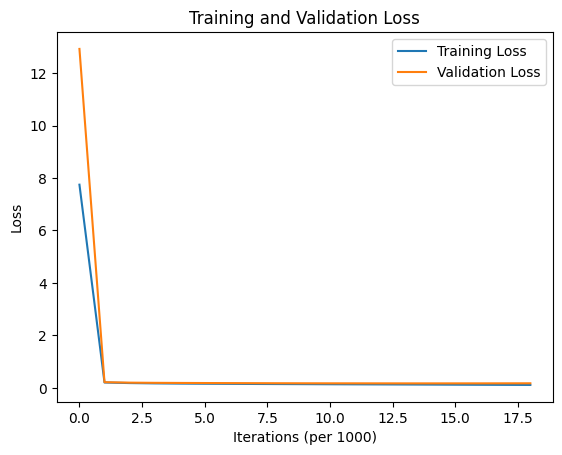

In [114]:
history_chart(train_loss_history, val_loss_history)

In [115]:
get_confusion_matrix(single_model, test_x, test_y)


============================== ZMAD ANN Model Test Results ==============================

Model Accuracy:
 0.9496945742005031

Confusion matrix:
 [[1102   83]
 [  57 1541]]

Classification report:
               precision    recall  f1-score   support

           0       0.95      0.93      0.94      1185
           1       0.95      0.96      0.96      1598

    accuracy                           0.95      2783
   macro avg       0.95      0.95      0.95      2783
weighted avg       0.95      0.95      0.95      2783




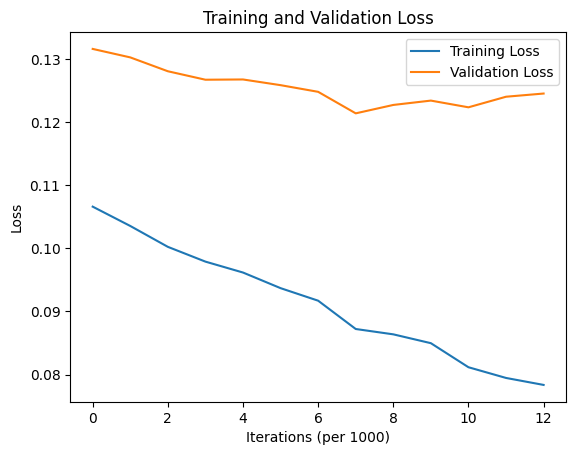

In [132]:
history_chart(train_loss_history_xav, val_loss_history_xav)

In [133]:
get_confusion_matrix(single_model_xav, test_x, test_y)


============================== ZMAD ANN Model Test Results ==============================

Model Accuracy:
 0.95400646784046

Confusion matrix:
 [[1096   89]
 [  39 1559]]

Classification report:
               precision    recall  f1-score   support

           0       0.97      0.92      0.94      1185
           1       0.95      0.98      0.96      1598

    accuracy                           0.95      2783
   macro avg       0.96      0.95      0.95      2783
weighted avg       0.95      0.95      0.95      2783




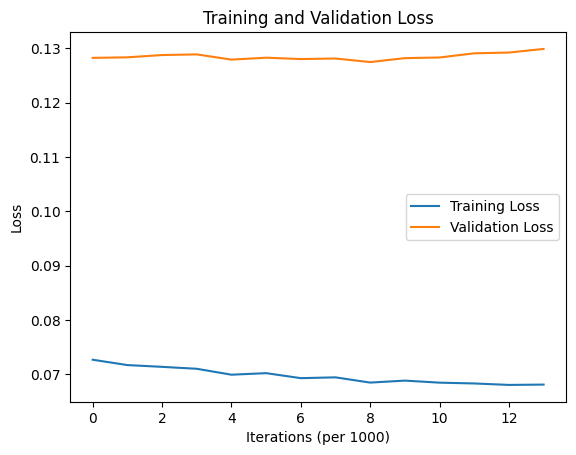

In [130]:
history_chart(train_loss_history_rand, val_loss_history_rand)

In [131]:
get_confusion_matrix(single_model_rand, test_x, test_y)


============================== ZMAD ANN Model Test Results ==============================

Model Accuracy:
 0.2738052461372619

Confusion matrix:
 [[ 720  465]
 [1556   42]]

Classification report:
               precision    recall  f1-score   support

           0       0.32      0.61      0.42      1185
           1       0.08      0.03      0.04      1598

    accuracy                           0.27      2783
   macro avg       0.20      0.32      0.23      2783
weighted avg       0.18      0.27      0.20      2783




# 5. Model Save

In [121]:
import pickle

In [122]:
single_model.save_params('single_he.pkl')

Parameters saved to single_he.pkl


In [123]:
single_model_xav.save_params('single_xav.pkl')

Parameters saved to single_xav.pkl


In [124]:
single_model_rand.save_params('single_xav.pkl')

Parameters saved to single_xav.pkl


# 6. Experiment
- First train on the old data, and then on the second-third data. (experimental model)
- Compare it with the model trained on the combined (all three) data. (comparison model)
- Drop RSSI, Speed features on the third dataset

In [12]:
third_df = third_df.drop(columns=['Speed', 'RSSI'])

## 6-1. Experimental model

In [46]:
train_x, train_y, val_x, val_y, test_x, test_y = data_splitter(first_df)

Total data count : 10496
Labels
0    4235
1    4161
Name: count, dtype: int64
Labels
0    543
1    507
Name: count, dtype: int64
Labels
0    547
1    503
Name: count, dtype: int64
****************************************************************************************************


In [47]:
input_size = 30
hidden_size = 32
learning_rate = 0.01
iterations = 100000
early_stopping_rounds=5000
tolerance=1e-4
init_method = 'xavier' # pick one from 'xavier', 'he', or 'random'

In [48]:
single_model_exp = SingleLayerPerceptron(input_size=input_size,
                                     hidden_size=hidden_size,
                                     learning_rate=learning_rate,
                                     iterations=100000,
                                     early_stopping_rounds=early_stopping_rounds,
                                     tolerance=tolerance,
                                     init_method=init_method)

In [49]:
train_loss_history, val_loss_history = single_model_exp.fit(train_x, train_y, val_x, val_y)

Iteration: 0
Training Loss: 8.570776118452853
Validation Loss: 4.786920380709995
Iteration: 1000
Training Loss: 0.1986733257329271
Validation Loss: 0.20437178343204404
Iteration: 2000
Training Loss: 0.15388964180674264
Validation Loss: 0.16260679587075472
Iteration: 3000
Training Loss: 0.13661762497078092
Validation Loss: 0.14998167217651914
Iteration: 4000
Training Loss: 0.12517951106337105
Validation Loss: 0.13972683400781405
Iteration: 5000
Training Loss: 0.11784570933294249
Validation Loss: 0.1374456440582721
Iteration: 6000
Training Loss: 0.11297203321527823
Validation Loss: 0.1289348806301583
Iteration: 7000
Training Loss: 0.11023290096286528
Validation Loss: 0.12646762722893762
Iteration: 8000
Training Loss: 0.10842885125692137
Validation Loss: 0.1258335916705092
Iteration: 9000
Training Loss: 0.1020404126553308
Validation Loss: 0.12903838682789034
Iteration: 10000
Training Loss: 0.09688769051902173
Validation Loss: 0.12337748595590055
Iteration: 11000
Training Loss: 0.095062381

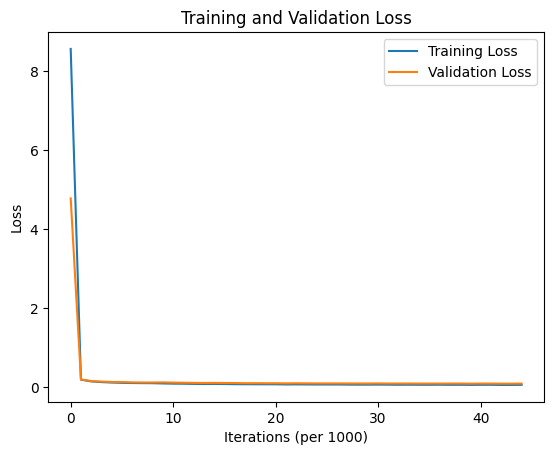

In [50]:
history_chart(train_loss_history, val_loss_history)

In [51]:
new_df = pd.concat([second_df, third_df], ignore_index=True)

In [52]:
train_x_sec, train_y_sec, val_x_sec, val_y_sec, test_x_sec, test_y_sec = data_splitter(new_df)

Total data count : 64009
Labels
1    32355
0    18852
Name: count, dtype: int64
Labels
1    4112
0    2289
Name: count, dtype: int64
Labels
1    4030
0    2371
Name: count, dtype: int64
****************************************************************************************************


In [53]:
train_loss_history_sec, val_loss_history_sec = single_model_exp.fit(train_x_sec, train_y_sec, val_x_sec, val_y_sec)

Iteration: 0
Training Loss: 5.021518398907783
Validation Loss: 4.9013153652287
Iteration: 1000
Training Loss: 0.2640844144185941
Validation Loss: 0.27744871528970483
Iteration: 2000
Training Loss: 0.24368758093738774
Validation Loss: 0.2583955268790463
Iteration: 3000
Training Loss: 0.23418706648494897
Validation Loss: 0.24692392123874174
Iteration: 4000
Training Loss: 0.22788042934557515
Validation Loss: 0.23968613566255162
Iteration: 5000
Training Loss: 0.22298227728183456
Validation Loss: 0.23433048206002183
Iteration: 6000
Training Loss: 0.2198475674899578
Validation Loss: 0.23120859747535633
Iteration: 7000
Training Loss: 0.21729167622738155
Validation Loss: 0.2294489962082698
Iteration: 8000
Training Loss: 0.21505972099310502
Validation Loss: 0.2279307316354997
Iteration: 9000
Training Loss: 0.2123721061292099
Validation Loss: 0.22566547857169691
Iteration: 10000
Training Loss: 0.21015790522886024
Validation Loss: 0.22377398494467202
Iteration: 11000
Training Loss: 0.208721248027

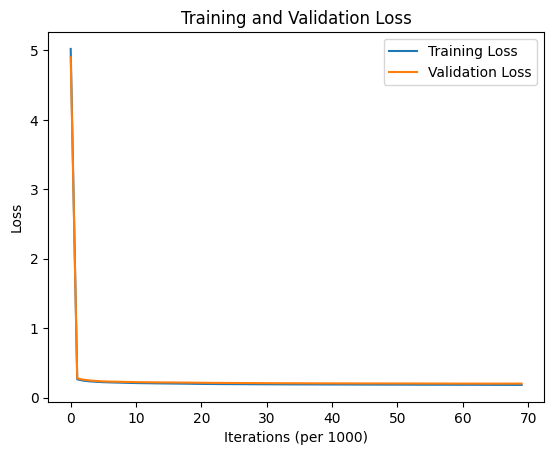

In [54]:
history_chart(train_loss_history_sec, val_loss_history_sec)

In [55]:
concat_test_x = np.hstack((test_x, test_x_sec))
concat_test_y = np.hstack((test_y, test_y_sec))

In [56]:
get_confusion_matrix(single_model_exp, concat_test_x, concat_test_y)


============================== ZMAD ANN Model Test Results ==============================

Model Accuracy:
 0.8967923768621662

Confusion matrix:
 [[2661  257]
 [ 512 4021]]

Classification report:
               precision    recall  f1-score   support

           0       0.84      0.91      0.87      2918
           1       0.94      0.89      0.91      4533

    accuracy                           0.90      7451
   macro avg       0.89      0.90      0.89      7451
weighted avg       0.90      0.90      0.90      7451




In [60]:
single_model_exp.save_params('params/single_exp.pkl')

Parameters saved to params/single_exp.pkl


## 6-2. Comparison model

In [40]:
concat_df = pd.concat([first_df, second_df, third_df], ignore_index=True)

In [ ]:
input_size = 30
hidden_size = 32
learning_rate = 0.01
iterations = 100000
early_stopping_rounds=5000
tolerance=1e-4
init_method = 'xavier' # pick one from 'xavier', 'he', or 'random'

In [42]:
train_x_concat, train_y_concat, val_x_concat, val_y_concat, test_x_concat, test_y_concat = data_splitter(concat_df)

Total data count : 74505
Labels
1    36478
0    23126
Name: count, dtype: int64
Labels
1    4584
0    2866
Name: count, dtype: int64
Labels
1    4606
0    2845
Name: count, dtype: int64
****************************************************************************************************


In [43]:
single_model_comp = SingleLayerPerceptron(input_size=input_size,
                                     hidden_size=hidden_size,
                                     learning_rate=learning_rate,
                                     iterations=100000,
                                     early_stopping_rounds=early_stopping_rounds,
                                     tolerance=tolerance,
                                     init_method=init_method)

In [44]:
train_loss_history_comp, val_loss_history_comp = single_model_comp.fit(train_x_concat, train_y_concat, val_x_concat, val_y_concat)

Iteration: 0
Training Loss: 4.562163232158998
Validation Loss: 9.92411197565133
Iteration: 1000
Training Loss: 0.3109307960638942
Validation Loss: 0.316520359800157
Iteration: 2000
Training Loss: 0.2800841386324286
Validation Loss: 0.2894203450822979
Iteration: 3000
Training Loss: 0.2660438803217623
Validation Loss: 0.27867945999173016
Iteration: 4000
Training Loss: 0.25686907896240396
Validation Loss: 0.27049781575714116
Iteration: 5000
Training Loss: 0.25110631988339843
Validation Loss: 0.26558358471100224
Iteration: 6000
Training Loss: 0.2460847020667901
Validation Loss: 0.26209001034942814
Iteration: 7000
Training Loss: 0.24251466873126176
Validation Loss: 0.2596671322205626
Iteration: 8000
Training Loss: 0.23894450601188139
Validation Loss: 0.2568519733834101
Iteration: 9000
Training Loss: 0.23566948312591454
Validation Loss: 0.2533385424964295
Iteration: 10000
Training Loss: 0.23276535633302803
Validation Loss: 0.2501894544768354
Iteration: 11000
Training Loss: 0.2294152041707667

In [ ]:
history_chart(train_loss_history_comp, val_loss_history_comp)

In [45]:
get_confusion_matrix(single_model_comp, test_x_concat, test_y_concat)


============================== ZMAD ANN Model Test Results ==============================

Model Accuracy:
 0.9310159710106026

Confusion matrix:
 [[2608  237]
 [ 277 4329]]

Classification report:
               precision    recall  f1-score   support

           0       0.90      0.92      0.91      2845
           1       0.95      0.94      0.94      4606

    accuracy                           0.93      7451
   macro avg       0.93      0.93      0.93      7451
weighted avg       0.93      0.93      0.93      7451




In [63]:
single_model_comp.save_params('params/single_comp.pkl')

Parameters saved to params/single_comp.pkl


# 7. Featrue Drop Experiment
- Drop features from val11 to val23 and see the difference in accuracy

In [67]:
concat_df.columns

Index(['SRC', 'P1', 'P2', 'LEN', 'DST', 'CMDCL', 'CMD', 'Val1', 'Val2', 'Val3',
       'Val4', 'Val5', 'Val6', 'Val7', 'Val8', 'Val9', 'Val10', 'Val11',
       'Val12', 'Val13', 'Val14', 'Val15', 'Val16', 'Val17', 'Val18', 'Val19',
       'Val20', 'Val21', 'Val22', 'Val23', 'Labels'],
      dtype='object')

In [68]:
drop_df = concat_df.drop(columns=['Val11', 'Val12', 'Val13', 'Val14', 'Val15', 'Val16', 'Val17', 'Val18', 'Val19', 'Val20', 'Val21', 'Val22', 'Val23'])

In [69]:
train_x_drop, train_y_drop, val_x_drop, val_y_drop, test_x_drop, test_y_drop = data_splitter(drop_df)

Total data count : 74505
Labels
1    36478
0    23126
Name: count, dtype: int64
Labels
1    4584
0    2866
Name: count, dtype: int64
Labels
1    4606
0    2845
Name: count, dtype: int64
****************************************************************************************************


In [76]:
input_size = 17
hidden_size = 32
learning_rate = 0.01
iterations = 100000
early_stopping_rounds=5000
tolerance=1e-4
init_method = 'xavier' # pick one from 'xavier', 'he', or 'random'

In [77]:
single_model_drop = SingleLayerPerceptron(input_size=input_size,
                                     hidden_size=hidden_size,
                                     learning_rate=learning_rate,
                                     iterations=100000,
                                     early_stopping_rounds=early_stopping_rounds,
                                     tolerance=tolerance,
                                     init_method=init_method)

In [78]:
train_loss_history_drop, val_loss_history_drop = single_model_drop.fit(train_x_drop, train_y_drop, val_x_drop, val_y_drop)

Iteration: 0
Training Loss: 6.4254166100690355
Validation Loss: 8.869357855295005
Iteration: 1000
Training Loss: 0.32466403405641037
Validation Loss: 0.3440815783350095
Iteration: 2000
Training Loss: 0.2924331456445773
Validation Loss: 0.3142618771573434
Iteration: 3000
Training Loss: 0.2722282072326622
Validation Loss: 0.29383482009155976
Iteration: 4000
Training Loss: 0.26005956609759845
Validation Loss: 0.27993537588970585
Iteration: 5000
Training Loss: 0.25146660145456723
Validation Loss: 0.27026892310967826
Iteration: 6000
Training Loss: 0.2442392225233423
Validation Loss: 0.2613529875398789
Iteration: 7000
Training Loss: 0.23877536197099464
Validation Loss: 0.2562820932148443
Iteration: 8000
Training Loss: 0.23397896118618258
Validation Loss: 0.25254000922909525
Iteration: 9000
Training Loss: 0.23018902957829557
Validation Loss: 0.24900326089626387
Iteration: 10000
Training Loss: 0.22735913965219168
Validation Loss: 0.24595942643766533
Iteration: 11000
Training Loss: 0.2251693838

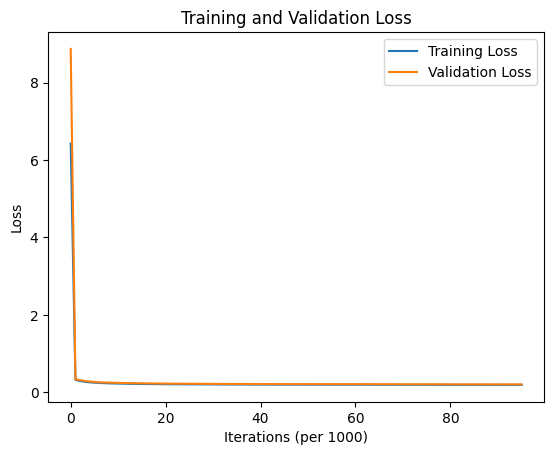

In [79]:
history_chart(train_loss_history_drop, val_loss_history_drop)

In [80]:
get_confusion_matrix(single_model_drop, test_x_drop, test_y_drop)


============================== ZMAD ANN Model Test Results ==============================

Model Accuracy:
 0.923902831834653

Confusion matrix:
 [[2583  262]
 [ 305 4301]]

Classification report:
               precision    recall  f1-score   support

           0       0.89      0.91      0.90      2845
           1       0.94      0.93      0.94      4606

    accuracy                           0.92      7451
   macro avg       0.92      0.92      0.92      7451
weighted avg       0.92      0.92      0.92      7451




In [82]:
single_model_drop.save_params('params/single_drop.pkl')

Parameters saved to params/single_drop.pkl


# 8. Using Momentum to Accelerate Training
- Update momentum based on the previous gradient

In [113]:
class SingleLayerPerceptron_Momentum:
    def __init__(self, input_size, hidden_size, learning_rate=0.01, iterations=10000, early_stopping_rounds=100, tolerance=1e-4, init_method='he', momentum=0.9):
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.output_size = 1
        self.learning_rate = learning_rate
        self.iterations = iterations
        self.early_stopping_rounds = early_stopping_rounds
        self.tolerance = tolerance
        self.init_method = init_method
        self.momentum = momentum
        self.W1, self.b1, self.W2, self.b2 = self.init_params()
        self.vdW1, self.vdb1, self.vdW2, self.vdb2 = 0, 0, 0, 0

    def init_params(self):
        if self.init_method == 'zero':
            W1 = np.zeros((self.hidden_size, self.input_size))
            b1 = np.zeros((self.hidden_size, 1))
            W2 = np.zeros((self.output_size, self.hidden_size))
            b2 = np.zeros((self.output_size, 1))
        elif self.init_method == 'random':
            W1 = np.random.randn(self.hidden_size, self.input_size) * 0.01
            b1 = np.random.randn(self.hidden_size, 1) * 0.01
            W2 = np.random.randn(self.output_size, self.hidden_size) * 0.01
            b2 = np.random.randn(self.output_size, 1) * 0.01
        elif self.init_method == 'he':
            W1 = np.random.randn(self.hidden_size, self.input_size) * np.sqrt(2. / self.input_size)
            b1 = np.random.randn(self.hidden_size, 1) * np.sqrt(2. / self.hidden_size)
            W2 = np.random.randn(self.output_size, self.hidden_size) * np.sqrt(2. / self.hidden_size)
            b2 = np.random.randn(self.output_size, 1) * np.sqrt(2. / self.output_size)
        elif self.init_method == 'xavier':
            W1 = np.random.randn(self.hidden_size, self.input_size) * np.sqrt(1. / self.input_size)
            b1 = np.random.randn(self.hidden_size, 1) * np.sqrt(1. / self.hidden_size)
            W2 = np.random.randn(self.output_size, self.hidden_size) * np.sqrt(1. / self.hidden_size)
            b2 = np.random.randn(self.output_size, 1) * np.sqrt(1. / self.output_size)
        else:
            raise ValueError(f"Unknown initialization method: {self.init_method}")
        return W1, b1, W2, b2

    @staticmethod
    def ReLU(Z):
        return np.maximum(Z, 0)

    @staticmethod
    def softmax(Z):
        A = np.exp(Z) / np.sum(np.exp(Z), axis=0)
        return A

    @staticmethod
    def sigmoid(x):
        return 1.0 / (1.0 + np.exp(-x))
    
    def forward_prop(self, X):
        Z1 = self.W1.dot(X) + self.b1
        A1 = self.ReLU(Z1)
        Z2 = self.W2.dot(A1) + self.b2
        A2 = self.sigmoid(Z2)
        return Z1, A1, Z2, A2

    @staticmethod
    def ReLU_deriv(Z):
        return Z > 0

    def compute_loss(self, A2, Y):
        m = Y.shape[0]
        epsilon = 1e-10  # 작은 값 추가하여 로그 0 방지
        log_probs = -Y * np.log(A2 + epsilon) - (1 - Y) * np.log(1 - A2 + epsilon)
        loss = np.sum(log_probs) / m
        return loss
    
    def backward_prop(self, Z1, A1, Z2, A2, X, Y):
        m = X.shape[1]
        dZ2 = A2 - Y
        dW2 = 1 / m * dZ2.dot(A1.T)
        db2 = 1 / m * np.sum(dZ2, axis=1, keepdims=True)
        dZ1 = self.W2.T.dot(dZ2) * self.ReLU_deriv(Z1)
        dW1 = 1 / m * dZ1.dot(X.T)
        db1 = 1 / m * np.sum(dZ1, axis=1, keepdims=True)
        return dW1, db1, dW2, db2

    def update_params(self, dW1, db1, dW2, db2):
        # 모멘텀을 사용하여 파라미터 업데이트
        self.vdW1 = self.momentum * self.vdW1 + self.learning_rate * dW1
        self.vdb1 = self.momentum * self.vdb1 + self.learning_rate * db1
        self.vdW2 = self.momentum * self.vdW2 + self.learning_rate * dW2
        self.vdb2 = self.momentum * self.vdb2 + self.learning_rate * db2

        self.W1 -= self.vdW1
        self.b1 -= self.vdb1
        self.W2 -= self.vdW2
        self.b2 -= self.vdb2

    @staticmethod
    def get_predictions(A2):
        return (A2 > 0.5).astype(int)
    
    @staticmethod
    def get_accuracy(predictions, Y):
        return np.sum(predictions == Y) / Y.size

    @staticmethod
    def get_f1_score(predictions, Y):
        return f1_score(Y.flatten(), predictions.flatten())
        
    def fit(self, X_train, Y_train, X_val, Y_val):
        train_loss_history = []
        val_loss_history = []
        best_loss = float('inf')
        best_iter = 0

        for i in range(self.iterations):
            Z1, A1, Z2, A2 = self.forward_prop(X_train)
            train_loss = self.compute_loss(A2, Y_train)
            dW1, db1, dW2, db2 = self.backward_prop(Z1, A1, Z2, A2, X_train, Y_train)
            self.update_params(dW1, db1, dW2, db2)

            if i % 1000 == 0:
                print(f"Iteration: {i}")
                train_loss_history.append(train_loss)
                print(f"Training Loss: {train_loss}")

                _, _, _, val_A2 = self.forward_prop(X_val)
                val_loss = self.compute_loss(val_A2, Y_val)
                val_loss_history.append(val_loss)
                print(f"Validation Loss: {val_loss}")

                if val_loss < best_loss - self.tolerance:
                    best_loss = val_loss
                    best_iter = i
                elif i - best_iter >= self.early_stopping_rounds:
                    print(f"Early stopping at iteration {i}")
                    break

        return train_loss_history, val_loss_history

    def predict(self, X):
        _, _, _, A2 = self.forward_prop(X)
        predictions = self.get_predictions(A2)
        return predictions.flatten()

    def save_params(self, file_path):
        params = {
            'W1': self.W1,
            'b1': self.b1,
            'W2': self.W2,
            'b2': self.b2
        }
        with open(file_path, 'wb') as file:
            pickle.dump(params, file)
        print(f"Parameters saved to {file_path}")

    def load_params(self, file_path):
        with open(file_path, 'rb') as file:
            params = pickle.load(file)
        self.W1 = params['W1']
        self.b1 = params['b1']
        self.W2 = params['W2']
        self.b2 = params['b2']
        print(f"Parameters loaded from {file_path}")

In [95]:
input_size = 30
hidden_size = 32
learning_rate = 0.01
iterations = 100000
early_stopping_rounds=10000
tolerance=1e-4
init_method = 'xavier' # pick one from 'xavier', 'he', or 'random'
momentum=0.5

In [96]:
single_model_mmt = SingleLayerPerceptron_Momentum(input_size=input_size,
                                     hidden_size=hidden_size,
                                     learning_rate=learning_rate,
                                     iterations=100000,
                                     early_stopping_rounds=early_stopping_rounds,
                                     tolerance=tolerance,
                                     init_method=init_method,
                                     momentum=momentum)

In [97]:
train_loss_history_mmt, val_loss_history_mmt = single_model_mmt.fit(train_x_concat, train_y_concat, val_x_concat, val_y_concat)

Iteration: 0
Training Loss: 4.8518770499454105
Validation Loss: 5.538854300301753
Iteration: 1000
Training Loss: 0.2951054037789634
Validation Loss: 0.29842686832747384
Iteration: 2000
Training Loss: 0.2649145611713346
Validation Loss: 0.27206606766467845
Iteration: 3000
Training Loss: 0.24748838335273496
Validation Loss: 0.25375711335313195
Iteration: 4000
Training Loss: 0.23336557976244943
Validation Loss: 0.23791215100302235
Iteration: 5000
Training Loss: 0.22537882564548342
Validation Loss: 0.2330964827942108
Iteration: 6000
Training Loss: 0.2199822402245055
Validation Loss: 0.2286763552591482
Iteration: 7000
Training Loss: 0.21600547221753752
Validation Loss: 0.2258562920546595
Iteration: 8000
Training Loss: 0.21232866114260338
Validation Loss: 0.22317258295112483
Iteration: 9000
Training Loss: 0.2089111777080393
Validation Loss: 0.22046166220480268
Iteration: 10000
Training Loss: 0.20602692671301706
Validation Loss: 0.21788082344208215
Iteration: 11000
Training Loss: 0.2026980109

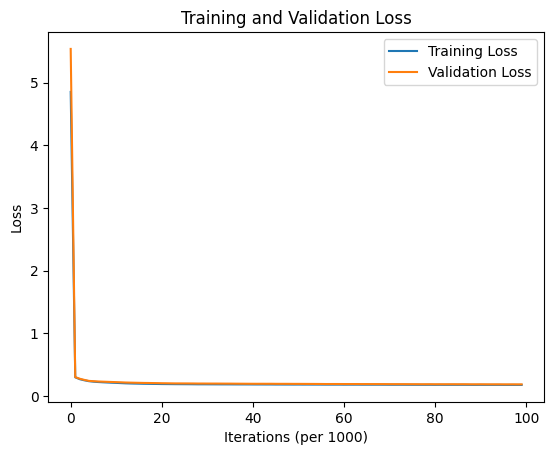

In [100]:
history_chart(train_loss_history_mmt, val_loss_history_mmt)

In [98]:
get_confusion_matrix(single_model_mmt, test_x_concat, test_y_concat)


============================== ZMAD ANN Model Test Results ==============================

Model Accuracy:
 0.929271238759898

Confusion matrix:
 [[2492  353]
 [ 174 4432]]

Classification report:
               precision    recall  f1-score   support

           0       0.93      0.88      0.90      2845
           1       0.93      0.96      0.94      4606

    accuracy                           0.93      7451
   macro avg       0.93      0.92      0.92      7451
weighted avg       0.93      0.93      0.93      7451




In [99]:
single_model_mmt.save_params('params/single_mmt.pkl')

Parameters saved to params/single_mmt.pkl


# 9. AUC Curve

In [ ]:
import numpy as np
from sklearn.metrics import roc_curve, precision_recall_curve, f1_score

# 모델 예측 확률
y_probs = model.predict_proba(X_test)[:, 1]

# ROC Curve 기반 임계값 선택 (Youden's J)
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
j_scores = tpr - fpr
optimal_idx = np.argmax(j_scores)
optimal_threshold_roc = thresholds[optimal_idx]

# Precision-Recall Curve 기반 임계값 선택 (F1 Score)
precisions, recalls, thresholds = precision_recall_curve(y_test, y_probs)
f1_scores = 2 * precisions * recalls / (precisions + recalls)
optimal_idx = np.argmax(f1_scores)
optimal_threshold_pr = thresholds[optimal_idx]

print(f'Optimal threshold (ROC): {optimal_threshold_roc}')
print(f'Optimal threshold (Precision-Recall): {optimal_threshold_pr}')

# 10. Result Collection

In [104]:
import pandas as pd

column_list = ['Model_Name', 'Input_Size', 'Learning_Rate', 'Epochs', 'Stop_Epoch',
               'Best_Loss', 'Final_Train_Loss', 'Final_Val_Loss', 'Accuracy', 'F1_Score', 'Note']

In [124]:
experiments = [
    ('single_exp', 30, 0.01, 100000, 69000, 0.20211, 0.18375, 0.20264, 0.89, 0.89, 'sequential training'),
    ('single_comp', 30, 0.01, 100000, 100000, 0.19867, 0.18078, 0.19867, 0.93, 0.93, 'combined training'),
    ('single_drop', 17, 0.01, 100000, 95000, 0.20704, 0.19294, 0.20703, 0.92, 0.92, 'dropped 13 features'),
    ('single_mmt', 30, 0.01, 100000, 100000, 0.18250, 0.17369, 0.18275, 0.93, 0.93, 'used momentum of 0.5'),
    ('single_nmt_2', 30, 0.03, 100000, 26000, 0.20501, 0.19287, 0.20955, 0.93, 0.93, 'used learning rate of 0.03')
]

In [125]:
experiment_results = pd.DataFrame(experiments, columns=column_list)

In [126]:
experiment_results

,Model_Name,Input_Size,Learning_Rate,Epochs,Stop_Epoch,Best_Loss,Final_Train_Loss,Final_Val_Loss,Accuracy,F1_Score,Note
0,single_exp,30,0.01,100000,69000,0.20211,0.18375,0.20264,0.89,0.89,sequential training
1,single_comp,30,0.01,100000,100000,0.19867,0.18078,0.19867,0.93,0.93,combined training
2,single_drop,17,0.01,100000,95000,0.20704,0.19294,0.20703,0.92,0.92,dropped 13 features
3,single_mmt,30,0.01,100000,100000,0.18250,0.17369,0.18275,0.93,0.93,used momentum of 0.5
4,single_nmt_2,30,0.03,100000,26000,0.20501,0.19287,0.20955,0.93,0.93,used learning rate of 0.03


In [127]:
experiment_results.to_csv('model_experiment.csv', index=False)

# 11. Further Improvement

In [119]:
input_size = 30
hidden_size = 32
learning_rate = 0.03
iterations = 100000
early_stopping_rounds=10000
tolerance=1e-4
init_method = 'xavier' # pick one from 'xavier', 'he', or 'random'
momentum=0.5

In [120]:
single_model_mmt_2 = SingleLayerPerceptron_Momentum(input_size=input_size,
                                     hidden_size=hidden_size,
                                     learning_rate=learning_rate,
                                     iterations=100000,
                                     early_stopping_rounds=early_stopping_rounds,
                                     tolerance=tolerance,
                                     init_method=init_method,
                                     momentum=momentum)

In [121]:
train_loss_history_mmt_2, val_loss_history_mmt_2 = single_model_mmt_2.fit(train_x_concat, train_y_concat, val_x_concat, val_y_concat)

Iteration: 0
Training Loss: 4.535692442479268
Validation Loss: 7.797697861537118
Iteration: 1000
Training Loss: 0.25944287598579524
Validation Loss: 0.2758926478640673
Iteration: 2000
Training Loss: 0.2349598001774523
Validation Loss: 0.24790151860170073
Iteration: 3000
Training Loss: 0.22067277867712648
Validation Loss: 0.2317510945438406
Iteration: 4000
Training Loss: 0.21665796337685927
Validation Loss: 0.22840604513878668
Iteration: 5000
Training Loss: 0.21395651917885752
Validation Loss: 0.22568799068599837
Iteration: 6000
Training Loss: 0.21154106756162053
Validation Loss: 0.22349349053308873
Iteration: 7000
Training Loss: 0.20906302749422956
Validation Loss: 0.2214366831467935
Iteration: 8000
Training Loss: 0.20601828578395529
Validation Loss: 0.21935953341415254
Iteration: 9000
Training Loss: 0.2048063015562213
Validation Loss: 0.21777650009784955
Iteration: 10000
Training Loss: 0.20348191049723455
Validation Loss: 0.2158548737786947
Iteration: 11000
Training Loss: 0.2010806618

In [123]:
get_confusion_matrix(single_model_mmt_2, test_x_concat, test_y_concat)


============================== ZMAD ANN Model Test Results ==============================

Model Accuracy:
 0.9276607166823245

Confusion matrix:
 [[2574  271]
 [ 268 4338]]

Classification report:
               precision    recall  f1-score   support

           0       0.91      0.90      0.91      2845
           1       0.94      0.94      0.94      4606

    accuracy                           0.93      7451
   macro avg       0.92      0.92      0.92      7451
weighted avg       0.93      0.93      0.93      7451




In [128]:
single_model_mmt_2.save_params('single_mmt_2.pkl')

Parameters saved to single_mmt_2.pkl


In [129]:
input_size = 30
hidden_size = 32
learning_rate = 0.03
iterations = 100000
early_stopping_rounds=10000
tolerance=1e-4
init_method = 'xavier' # pick one from 'xavier', 'he', or 'random'
momentum=0.3

In [130]:
single_model_mmt_3 = SingleLayerPerceptron_Momentum(input_size=input_size,
                                     hidden_size=hidden_size,
                                     learning_rate=learning_rate,
                                     iterations=100000,
                                     early_stopping_rounds=early_stopping_rounds,
                                     tolerance=tolerance,
                                     init_method=init_method,
                                     momentum=momentum)

In [131]:
train_loss_history_mmt_3, val_loss_history_mmt_3 = single_model_mmt_3.fit(train_x_concat, train_y_concat, val_x_concat, val_y_concat)

Iteration: 0
Training Loss: 8.078707110835234
Validation Loss: 8.812715748135524
Iteration: 1000
Training Loss: 0.2999226143597541
Validation Loss: 0.31295847190846354
Iteration: 2000
Training Loss: 0.27538469865816245
Validation Loss: 0.2904484300795971
Iteration: 3000
Training Loss: 0.2659419249862856
Validation Loss: 0.2805090073262581
Iteration: 4000
Training Loss: 0.25091604783206506
Validation Loss: 0.2652818524690096
Iteration: 5000
Training Loss: 0.24479735877039782
Validation Loss: 0.2590824527129892
Iteration: 6000
Training Loss: 0.24189066077484056
Validation Loss: 0.2541698137226602
Iteration: 7000
Training Loss: 0.2393353046708889
Validation Loss: 0.2516252141902579
Iteration: 8000
Training Loss: 0.2368815376079901
Validation Loss: 0.24924733087186535
Iteration: 9000
Training Loss: 0.23458659182336464
Validation Loss: 0.24715431831474702
Iteration: 10000
Training Loss: 0.23272993782555382
Validation Loss: 0.2453986465427242
Iteration: 11000
Training Loss: 0.231342637033114

In [142]:
get_confusion_matrix(single_model_mmt_3, test_x_concat, test_y_concat)


============================== ZMAD ANN Model Test Results ==============================

Model Accuracy:
 0.9232317809689975

Confusion matrix:
 [[2552  293]
 [ 279 4327]]

Classification report:
               precision    recall  f1-score   support

           0       0.90      0.90      0.90      2845
           1       0.94      0.94      0.94      4606

    accuracy                           0.92      7451
   macro avg       0.92      0.92      0.92      7451
weighted avg       0.92      0.92      0.92      7451




In [141]:
single_model_mmt_3.save_params('params/single_mmt_2.pkl')

Parameters saved to params/single_mmt_2.pkl


In [39]:
30*256+256*64+64*1+256+64+1

24449

# Experiment on initialization

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

In [87]:
history = pd.read_csv('Training_loss.csv')

In [106]:
history

,epoch,zero-t,random-t,xavier-t,he-t,zero-v,random-v,xavier-v,he-v
0,0k,0.693147,0.691935,3.904858,7.594058,0.693108,0.691787,2.201816,3.839244
1,1k,0.667842,0.225405,0.210676,0.233404,0.666341,0.240773,0.238461,0.256590
2,2k,0.667842,0.199928,0.186999,0.199442,0.666340,0.196847,0.208180,0.218745
3,3k,0.667842,0.185136,0.169695,0.182055,0.666340,0.183333,0.187518,0.198785
4,4k,0.667842,0.178349,0.155552,0.168474,0.666340,0.175811,0.173267,0.186903
5,5k,0.667842,0.170109,0.145198,0.167382,0.666340,0.168497,0.168763,0.182074
6,6k,0.667842,0.164603,0.141340,0.159477,0.666340,0.174946,0.164319,0.177969
7,7k,NaN,0.189756,0.139036,0.151892,NaN,0.215836,0.161062,0.179315
8,8k,NaN,0.166520,0.149521,0.158185,NaN,0.168264,0.160107,0.180383
9,9k,NaN,0.156545,0.140216,0.149724,NaN,0.160332,0.162378,0.174706


In [110]:
zero_hist = history.dropna(subset=['zero-t', 'zero-v']).iloc[:, [0, 1, 5]]
random_hist = history.dropna(subset=['random-t', 'random-v']).iloc[:, [0, 2, 6]]
xav_hist = history.dropna(subset=['xavier-t', 'xavier-v']).iloc[:, [0, 3, 7]]
he_hist = history.dropna(subset=['he-t', 'he-v']).iloc[:, [0, 4, 8]]

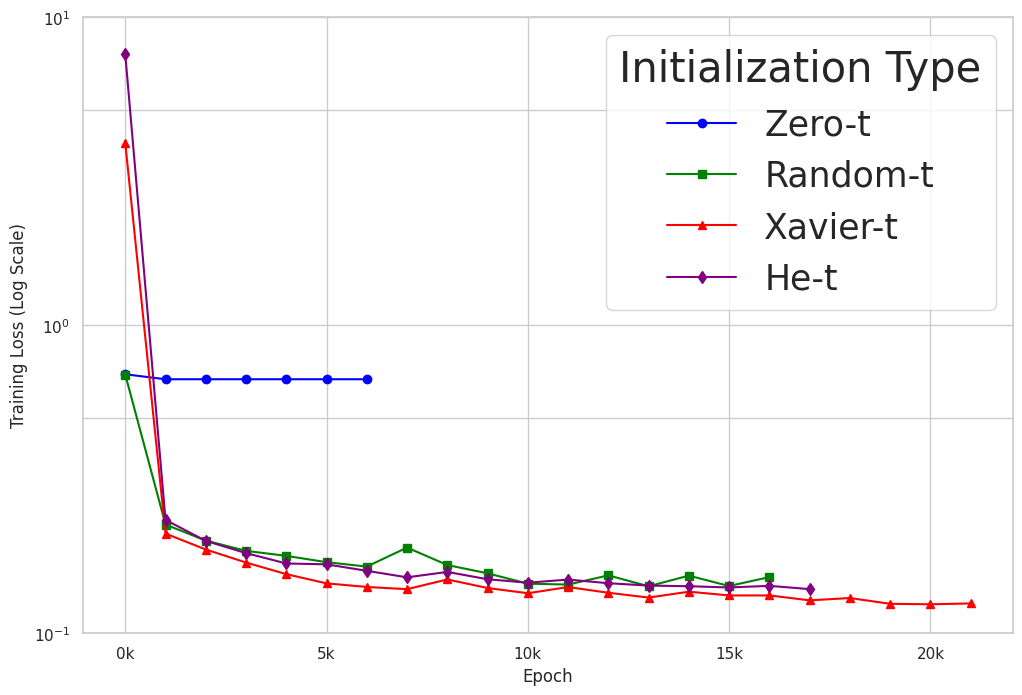

In [134]:
# Plotting
plt.figure(figsize=(12, 8))

# Zero Initialization
plt.plot(zero_hist.iloc[:, 0], zero_hist.iloc[:, 1], label='Zero-t', color='blue', linestyle='-', marker='o')

# Random Initialization
plt.plot(random_hist.iloc[:, 0], random_hist.iloc[:, 1], label='Random-t', color='green', linestyle='-', marker='s')

# Xavier Initialization
plt.plot(xav_hist.iloc[:, 0], xav_hist.iloc[:, 1], label='Xavier-t', color='red', linestyle='-', marker='^')

# He Initialization
plt.plot(he_hist.iloc[:, 0], he_hist.iloc[:, 1], label='He-t', color='purple', linestyle='-', marker='d')

# Customize the plot
plt.xlabel('Epoch')
plt.ylabel('Training Loss (Log Scale)')
plt.legend()

# Apply logarithmic scale to y-axis
plt.yscale('log')

epoch_ticks = range(0, 21, 5)
plt.xticks(epoch_ticks)
y_ticks = [0.1, 0.5, 1, 5, 10]
plt.yticks(y_ticks)

plt.legend(loc="upper right", title="Initialization Type", fontsize=25, title_fontsize=30)

plt.savefig("train_loss.png")
# Show plot
plt.show()

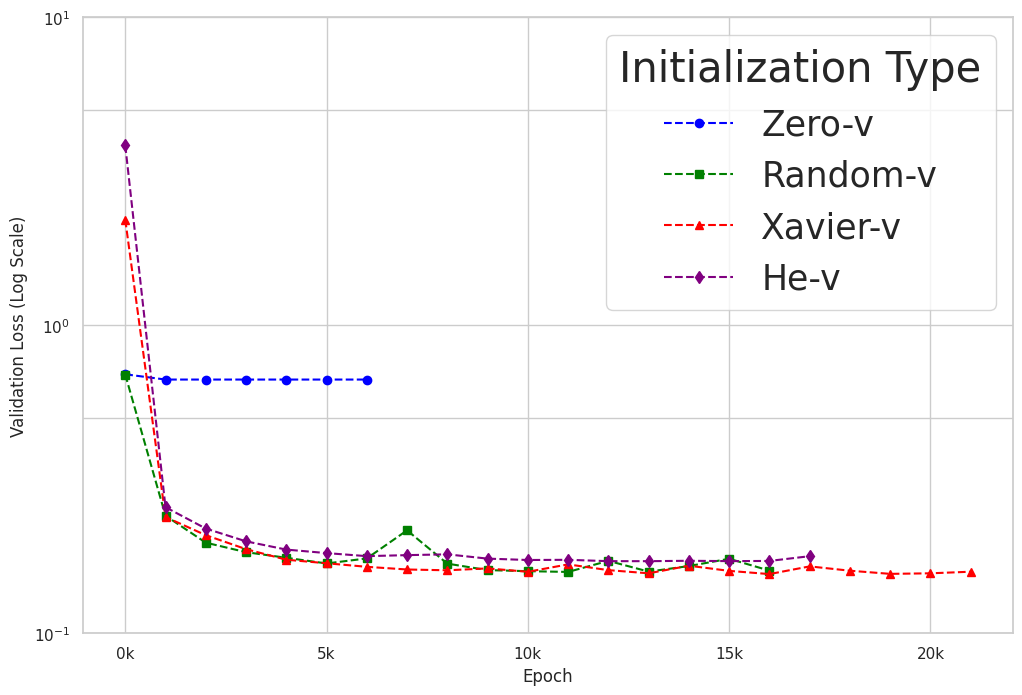

In [135]:
# Plotting
plt.figure(figsize=(12, 8))

plt.plot(zero_hist.iloc[:, 0], zero_hist.iloc[:, 2], label='Zero-v', color='blue', linestyle='--', marker='o')
plt.plot(random_hist.iloc[:, 0], random_hist.iloc[:, 2], label='Random-v', color='green', linestyle='--', marker='s')
plt.plot(xav_hist.iloc[:, 0], xav_hist.iloc[:, 2], label='Xavier-v', color='red', linestyle='--', marker='^')
plt.plot(he_hist.iloc[:, 0], he_hist.iloc[:, 2], label='He-v', color='purple', linestyle='--', marker='d')

# Customize the plot
plt.xlabel('Epoch')
plt.ylabel('Validation Loss (Log Scale)')
plt.legend()

# Apply logarithmic scale to y-axis
plt.yscale('log')

epoch_ticks = range(0, 21, 5)
plt.xticks(epoch_ticks)

y_ticks = [0.1, 0.5, 1, 5, 10]
plt.yticks(y_ticks)

plt.legend(loc="upper right", title="Initialization Type", fontsize=25, title_fontsize=30)
plt.savefig('val_loss.png')

# Show plot
plt.show()

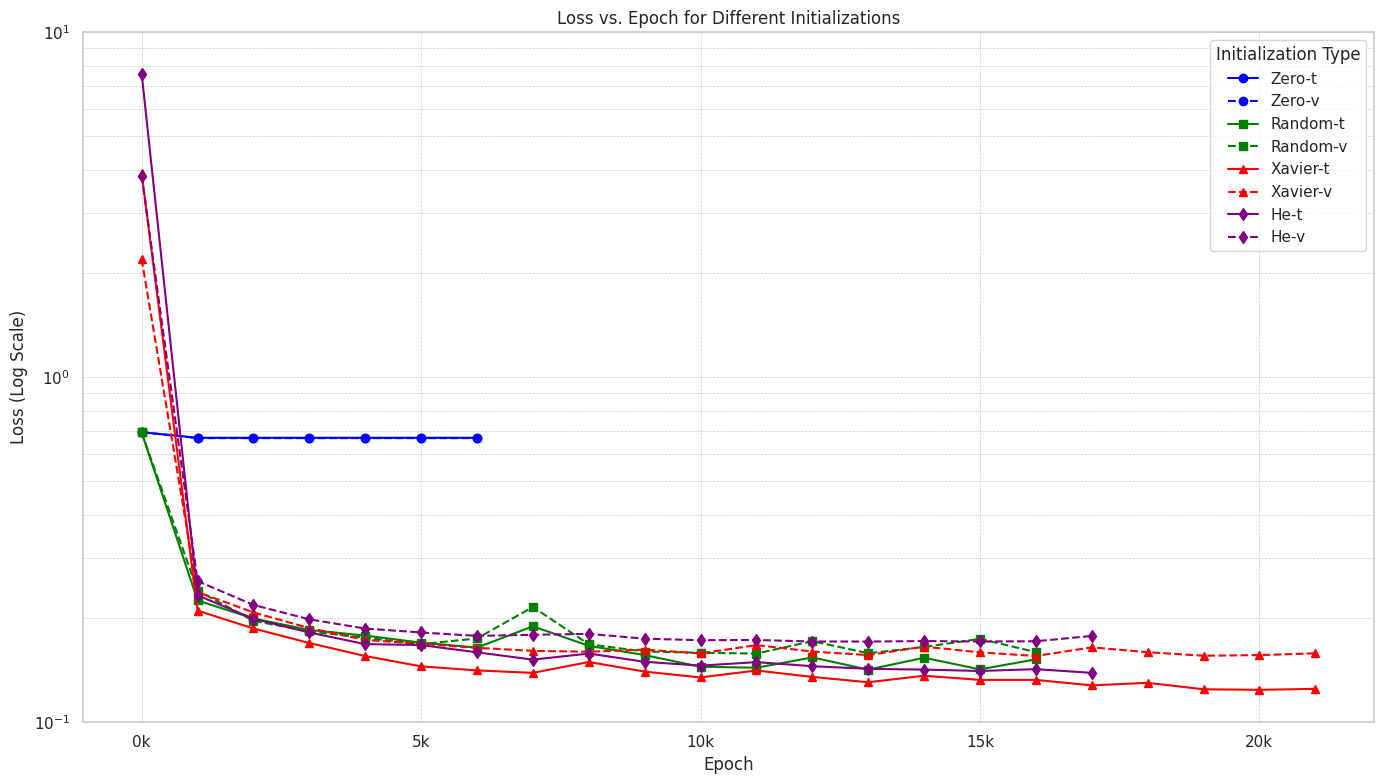

In [ ]:
# Set the Seaborn style
sns.set(style="whitegrid")

# Assuming `history` is your original DataFrame

# Preprocess data (already done in your case)
zero_hist = history.dropna(subset=['zero-t', 'zero-v']).iloc[:, [0, 1, 5]]
random_hist = history.dropna(subset=['random-t', 'random-v']).iloc[:, [0, 2, 6]]
xav_hist = history.dropna(subset=['xavier-t', 'xavier-v']).iloc[:, [0, 3, 7]]
he_hist = history.dropna(subset=['he-t', 'he-v']).iloc[:, [0, 4, 8]]

# Plotting
plt.figure(figsize=(14, 8))

# Zero Initialization
plt.plot(zero_hist.iloc[:, 0], zero_hist.iloc[:, 1], label='Zero-t', color='blue', linestyle='-', marker='o')
plt.plot(zero_hist.iloc[:, 0], zero_hist.iloc[:, 2], label='Zero-v', color='blue', linestyle='--', marker='o')

# Random Initialization
plt.plot(random_hist.iloc[:, 0], random_hist.iloc[:, 1], label='Random-t', color='green', linestyle='-', marker='s')
plt.plot(random_hist.iloc[:, 0], random_hist.iloc[:, 2], label='Random-v', color='green', linestyle='--', marker='s')

# Xavier Initialization
plt.plot(xav_hist.iloc[:, 0], xav_hist.iloc[:, 1], label='Xavier-t', color='red', linestyle='-', marker='^')
plt.plot(xav_hist.iloc[:, 0], xav_hist.iloc[:, 2], label='Xavier-v', color='red', linestyle='--', marker='^')

# He Initialization
plt.plot(he_hist.iloc[:, 0], he_hist.iloc[:, 1], label='He-t', color='purple', linestyle='-', marker='d')
plt.plot(he_hist.iloc[:, 0], he_hist.iloc[:, 2], label='He-v', color='purple', linestyle='--', marker='d')

# Customize the plot
plt.xlabel('Epoch')
plt.ylabel('Loss (Log Scale)')
plt.title('Loss vs. Epoch for Different Initializations')
plt.legend(loc="upper right", title="Initialization Type")
plt.grid(True, which="both", linestyle="--", linewidth=0.5)

# Apply logarithmic scale to y-axis
plt.yscale('log')

# Show plot
plt.tight_layout()
plt.show()